# Insurance Claims & Portfolio Risk Dashboard
## Python Analysis Notebook

This notebook documents the analytical workflow for a descriptive insurance portfolio analysis. It will be expanded phase by phase, beginning with business understanding before any data is loaded or transformed.

## 0. Project Status

**Completed:** Phase 1 - Business Understanding; Phase 2 - Environment and Repository Setup.

No dataset has been acquired, inspected, cleaned, or analysed at this point. Those steps are deliberately deferred to the later phases so that the business context and measurement logic are clear first.

# 1. Business Understanding

## 1.1 Business Scenario

The audience is the motor-insurance company's management team. They need a clear portfolio view to support discussions about where claims occur frequently, where claim costs are elevated, which policy segments need closer monitoring, and which indicators should be tracked in the next reporting cycle. This is a **descriptive analytics / business-intelligence** project: it describes observed portfolio patterns and supports exploration through a Tableau dashboard. It does not estimate prices, select underwriting actions automatically, or establish causal relationships.

## 1.2 Management Questions

1. What is the overall health of the insurance portfolio?
2. Which regions generate the greatest claim burden?
3. Which driver and vehicle segments show different claim patterns?
4. Are frequent-claim segments also expensive-claim segments?
5. Is claim cost concentrated in a small number of claims or policies?
6. What unusual claims or segments should management investigate?
7. What should management monitor every month?
8. What are the three data-driven recommendations?

## 1.3 Analytical Constraints

The analysis must follow these rules:

- **Do not calculate Loss Ratio.** The selected dataset does not contain written premium.
- **Do not use raw claim count alone as a risk measure.** Claims must be interpreted with exposure and portfolio size.
- **Do not claim causation.** Findings describe associations observed in this dataset.
- **Do not automatically delete large claims.** Monetary insurance data are usually skewed; extreme values must be investigated and documented first.
- **Do not hide cleaning in Tableau.** Cleaning, aggregation, merge logic, and feature engineering must be documented in Python before export.

## 1.4 KPI Glossary

| KPI | Definition | Calculation / interpretation |
|---|---|---|
| Policy Count | Number of distinct policies in the selected portfolio or segment. | `nunique(IDpol)` |
| Exposure | Total observed policy time in years. | `sum(Exposure)` |
| Claim Count | Number of reported claims during the observed exposure. | `sum(ClaimNb)` |
| Claim Frequency | Claim occurrence adjusted for the amount of policy exposure, expressed as claims per exposure year. | `Claim Count / Exposure` |
| Total Claim Cost | Aggregate cost of observed claims. | `sum(ClaimAmount)`; after a policy-level merge, use the aggregated policy claim-cost field. |
| Average Severity | Average cost among observed claims represented in the severity data. | `Total Claim Cost / number of observed severity claims`; repeated claims on one policy must be handled explicitly. |

Frequency and severity answer different questions. A segment may have frequent but lower-cost claims, or infrequent but costly claims. Segment comparisons will therefore always retain both measures alongside exposure.

# 2. Environment and Repository Setup

The project uses an isolated Python virtual environment (`.venv`) and version-pinned dependencies in `requirements.txt`. Raw source data and processed outputs are stored separately so that original files remain unchanged and Tableau-ready data can be regenerated from documented Python steps.

In [1]:
from importlib.metadata import version

for package in ["pandas", "numpy", "matplotlib", "openpyxl", "jupyter"]:
    print(f"{package}: {version(package)}")

pandas: 3.0.6
numpy: 2.5.3
matplotlib: 3.11.2
openpyxl: 3.1.5
jupyter: 1.1.1


## Phase 2 Learning Checkpoint

- A virtual environment isolates this project's packages from the system Python and from other projects, making dependency conflicts less likely.
- `requirements.txt` records the project's required packages and exact versions so another person can recreate a compatible environment.
- Keeping raw and processed data separate preserves the original source, creates an audit trail for transformations, and makes the Tableau export reproducible.

# 3. Acquire and Understand the Dataset

## 3.1 Source Dataset

This project uses the **French Motor Third-Party Liability (`freMTPL2`)** datasets from the [CASdatasets package](https://github.com/dutangc/CASdatasets). The source describes an anonymized portfolio from an unknown private insurer. The official documentation reports 677,991 motor third-party liability policies observed mostly over one year.

The unchanged source files were downloaded on **2026-09-19** into `data/raw/` as `freMTPL2freq.rda` and `freMTPL2sev.rda`. Their download links and SHA-256 checksums are recorded in [`data/README.md`](../data/README.md).

## 3.2 Data Grain and Table Relationship

`freMTPL2freq` is a **policy-level** table: each row represents a policy and contains its exposure, claim count, and risk attributes. `freMTPL2sev` is a **claim-level** table: each row records a claim amount and the `IDpol` of the policy to which it belongs.

The tables are separate because policy characteristics and exposure are recorded once per policy, while a policy can generate zero, one, or several claims. A direct row-level merge would repeat the policy row for every matching severity record. That would duplicate exposure and policy attributes and would distort policy-level totals. In the merge phase, claim amounts will first be aggregated by `IDpol`, then joined to the policy table.

## 3.3 Data Dictionary

| Variable | Meaning | Table |
|---|---|---|
| `IDpol` | Policy identifier used to link the tables. | Frequency and Severity |
| `ClaimNb` | Number of claims during the exposure period. | Frequency |
| `Exposure` | Policy exposure period in years. | Frequency |
| `VehPower` | Ordered vehicle-power category. | Frequency |
| `VehAge` | Vehicle age in years. | Frequency |
| `DrivAge` | Driver age in years. | Frequency |
| `BonusMalus` | French bonus/malus coefficient. | Frequency |
| `VehBrand` | Vehicle-brand category. | Frequency |
| `VehGas` | Fuel type: Diesel or Regular. | Frequency |
| `Area` | Driver-community density category from A (rural) to F (urban centre). | Frequency |
| `Density` | Population density of the driver's community, in inhabitants per square kilometre. | Frequency |
| `Region` | Policy region in France, using the 1970-2015 classification. | Frequency |
| `ClaimAmount` | Cost of an observed claim. | Severity |

## Phase 3 Learning Checkpoint

- Frequency and severity are separated because they have different grains: policy attributes and exposure belong to a policy, whereas claim cost belongs to an individual claim.
- A merge cannot be performed blindly because the same `IDpol` can occur in several severity rows. Joining those rows directly to the frequency table would duplicate policy-level values.
- One policy may correspond to multiple claims because `ClaimNb` counts claims during its exposure period; the severity table therefore may contain several claim amounts associated with that policy.

# 4. Initial Data Inspection

The source files are stored in RDA format. This notebook uses `rdata` to load each original table into a pandas DataFrame for inspection. No values are changed in this phase.

In [2]:
from pathlib import Path

import pandas as pd
import rdata
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

def load_rda_table(path: Path) -> pd.DataFrame:
    """Load the one table stored in an RDA source file."""
    objects = rdata.read_rda(path)
    if len(objects) != 1:
        raise ValueError(f"Expected one table in {path.name}; found {len(objects)}.")
    return next(iter(objects.values()))

freq = load_rda_table(RAW_DATA_DIR / "freMTPL2freq.rda")
sev = load_rda_table(RAW_DATA_DIR / "freMTPL2sev.rda")

In [3]:
shape_summary = pd.DataFrame(
    {"Rows": [freq.shape[0], sev.shape[0]], "Columns": [freq.shape[1], sev.shape[1]]},
    index=["Frequency", "Severity"],
)
shape_summary

,Rows,Columns
Frequency,677991,12
Severity,26444,2


In [4]:
display(freq.head())
display(sev.head())

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
1,1,0.0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
2,3,0.0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes
3,5,0.0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie
4,10,0.0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine
5,11,0.0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine


,IDpol,ClaimAmount
1,1552,995.20
2,1010996,1128.12
3,4024277,1851.11
4,4007252,1204.00
5,4046424,1204.00


In [5]:
dtype_summary = pd.concat(
    [freq.dtypes.rename("Frequency dtype"), sev.dtypes.rename("Severity dtype")],
    axis=1,
)
display(dtype_summary)

print("Frequency table info")
freq.info()
print("\nSeverity table info")
sev.info()

,Frequency dtype,Severity dtype
IDpol,category,category
ClaimNb,float64,NaN
Exposure,float64,NaN
VehPower,Int32,NaN
VehAge,Int32,NaN
DrivAge,Int32,NaN
BonusMalus,Int32,NaN
VehBrand,category,NaN
VehGas,category,NaN
Area,category,NaN


Frequency table info
<class 'pandas.DataFrame'>
Index: 677991 entries, 1 to 678013
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   IDpol       677991 non-null  category
 1   ClaimNb     677991 non-null  float64 
 2   Exposure    677991 non-null  float64 
 3   VehPower    677991 non-null  Int32   
 4   VehAge      677991 non-null  Int32   
 5   DrivAge     677991 non-null  Int32   
 6   BonusMalus  677991 non-null  Int32   
 7   VehBrand    677991 non-null  category
 8   VehGas      677991 non-null  category
 9   Area        677991 non-null  category
 10  Density     677991 non-null  Int32   
 11  Region      677991 non-null  category
dtypes: Int32(5), category(5), float64(2)
memory usage: 58.2+ MB

Severity table info
<class 'pandas.DataFrame'>
Index: 26444 entries, 1 to 26639
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   IDpol        

In [6]:
display(freq.describe(include="all"))
display(sev.describe(include="all"))

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region
count,677991,677991.000000,677991.000000,677991.0,677991.0,677991.0,677991.0,677991,677991,677991,677991.0,677991
unique,677991,NaN,NaN,<NA>,<NA>,<NA>,<NA>,11,2,6,<NA>,22
top,1,NaN,NaN,<NA>,<NA>,<NA>,<NA>,B12,Regular,C,<NA>,Centre
freq,1,NaN,NaN,<NA>,<NA>,<NA>,<NA>,166022,345863,191874,<NA>,160595
mean,NaN,0.039003,0.528743,6.454649,7.044244,45.499092,59.761559,NaN,NaN,NaN,1792.406856,NaN
std,NaN,0.207169,0.364441,2.050914,5.666226,14.137449,15.636713,NaN,NaN,NaN,3958.574057,NaN
min,NaN,0.000000,0.002732,4.0,0.0,18.0,50.0,NaN,NaN,NaN,1.0,NaN
25%,NaN,0.000000,0.180000,5.0,2.0,34.0,50.0,NaN,NaN,NaN,92.0,NaN
50%,NaN,0.000000,0.490000,6.0,6.0,44.0,50.0,NaN,NaN,NaN,393.0,NaN
75%,NaN,0.000000,0.990000,7.0,11.0,55.0,64.0,NaN,NaN,NaN,1658.0,NaN


,IDpol,ClaimAmount
count,26444,2.644400e+04
unique,24944,NaN
top,2241683,NaN
freq,16,NaN
mean,NaN,2.265513e+03
std,NaN,2.937103e+04
min,NaN,1.000000e+00
25%,NaN,6.859925e+02
50%,NaN,1.172000e+03
75%,NaN,1.212385e+03


In [7]:
id_summary = pd.DataFrame(
    {
        "Rows": [len(freq), len(sev)],
        "Unique IDpol": [freq["IDpol"].nunique(), sev["IDpol"].nunique()],
    },
    index=["Frequency", "Severity"],
)
id_summary["Rows beyond first IDpol occurrence"] = id_summary["Rows"] - id_summary["Unique IDpol"]
id_summary

,Rows,Unique IDpol,Rows beyond first IDpol occurrence
Frequency,677991,677991,0
Severity,26444,24944,1500


In [8]:
categorical_columns = ["VehBrand", "VehGas", "Area", "Region"]
category_counts = {}

for column in categorical_columns:
    counts = freq[column].value_counts(dropna=False).sort_index().rename("Policy Count")
    category_counts[column] = counts
    print(f"{column}: {counts.size} levels")
    display(counts.to_frame())

VehBrand: 11 levels


,Policy Count
VehBrand,
B1,162730
B10,17707
B11,13585
B12,166022
B13,12177
B14,4047
B2,159854
B3,53393
B4,25179


VehGas: 2 levels


,Policy Count
VehGas,
Diesel,332128
Regular,345863


Area: 6 levels


,Policy Count
Area,
A,103952
B,75457
C,191874
D,151592
E,137163
F,17953


Region: 22 levels


,Policy Count
Region,
Alsace,2200
Aquitaine,31329
Auvergne,5287
Basse-Normandie,10892
Bourgogne,10491
Bretagne,42120
Centre,160595
Champagne-Ardenne,3025
Corse,4516


In [9]:
numeric_skewness = pd.concat(
    [
        freq.select_dtypes(include="number").skew().rename("Frequency skewness"),
        sev.select_dtypes(include="number").skew().rename("Severity skewness"),
    ],
    axis=1,
).sort_values(by=["Severity skewness", "Frequency skewness"], ascending=False, na_position="last")
numeric_skewness

,Frequency skewness,Severity skewness
ClaimAmount,<NA>,109.529865
ClaimNb,6.796098,NaN
Density,4.65145,NaN
BonusMalus,1.728934,NaN
VehPower,1.171346,NaN
VehAge,1.148011,NaN
DrivAge,0.435773,NaN
Exposure,0.085351,NaN


## Phase 4 Learning Checkpoint

### Is `IDpol` unique?

- **Frequency:** Yes. It has 677,991 rows and 677,991 unique `IDpol` values, so one row represents one policy.
- **Severity:** No. It has 26,444 rows but 24,944 unique `IDpol` values. The extra 1,500 rows occur because some policies have more than one recorded claim.

### Which columns are numeric and categorical?

- **Numeric measures:** `ClaimNb`, `Exposure`, `VehPower`, `VehAge`, `DrivAge`, `BonusMalus`, `Density`, and `ClaimAmount`. `IDpol` is stored as a category because it is an identifier rather than a quantity to aggregate.
- **Categorical variables:** `VehBrand` (11 levels), `VehGas` (2), `Area` (6), and `Region` (22).

### Which variables appear skewed?

`ClaimAmount` is extremely right-skewed: its mean is 2,265.51, median is 1,172.00, maximum is 4,075,401.00, and sample skewness is 109.53. `ClaimNb` (6.80) and `Density` (4.65) are also strongly right-skewed. `BonusMalus`, `VehPower`, and `VehAge` show moderate positive skewness, while `Exposure` is close to symmetric (0.09). These are observations for later investigation, not grounds to remove values in this phase.

# 5. Data Quality Checks

This phase separates confirmed data-quality issues from valid but unusual insurance observations. The checks below inspect the original loaded DataFrames. Any future transformation must be traceable to an explicit decision recorded in this section.

In [10]:
missing_values = pd.concat(
    [freq.isna().sum().rename("Frequency missing"), sev.isna().sum().rename("Severity missing")],
    axis=1,
).fillna("Not present in table")
missing_values

,Frequency missing,Severity missing
IDpol,0.0,0.0
ClaimNb,0.0,Not present in table
Exposure,0.0,Not present in table
VehPower,0.0,Not present in table
VehAge,0.0,Not present in table
DrivAge,0.0,Not present in table
BonusMalus,0.0,Not present in table
VehBrand,0.0,Not present in table
VehGas,0.0,Not present in table
Area,0.0,Not present in table


In [11]:
duplicate_summary = pd.DataFrame(
    {
        "Exact duplicate rows": [freq.duplicated().sum(), sev.duplicated().sum()],
        "Duplicate IDpol values": [freq["IDpol"].duplicated().sum(), sev["IDpol"].duplicated().sum()],
    },
    index=["Frequency", "Severity"],
)
display(duplicate_summary)

severity_duplicate_groups = (
    sev.groupby(["IDpol", "ClaimAmount"], observed=True)
    .size()
    .rename("Occurrences")
)
severity_duplicate_groups = severity_duplicate_groups[severity_duplicate_groups > 1]

duplicate_group_summary = pd.DataFrame(
    {
        "Duplicate groups": [len(severity_duplicate_groups)],
        "Policies represented": [severity_duplicate_groups.reset_index()["IDpol"].nunique()],
        "Rows in duplicate groups": [severity_duplicate_groups.sum()],
        "Rows beyond first occurrence": [(severity_duplicate_groups - 1).sum()],
        "Largest group": [severity_duplicate_groups.max()],
    }
)
display(duplicate_group_summary)
display(severity_duplicate_groups.value_counts().sort_index().rename("Number of groups").to_frame())

,Exact duplicate rows,Duplicate IDpol values
Frequency,0,0
Severity,235,1500


,Duplicate groups,Policies represented,Rows in duplicate groups,Rows beyond first occurrence,Largest group
0,229,227,464,235,4


,Number of groups
Occurrences,
2,224
3,4
4,1


In [12]:
exposure_q1 = freq["Exposure"].quantile(0.25)
exposure_q3 = freq["Exposure"].quantile(0.75)
exposure_iqr_upper_fence = exposure_q3 + 1.5 * (exposure_q3 - exposure_q1)

exposure_checks = pd.Series(
    {
        "Zero exposure": (freq["Exposure"] == 0).sum(),
        "Negative exposure": (freq["Exposure"] < 0).sum(),
        "Exposure above 1 year": (freq["Exposure"] > 1).sum(),
        "Exposure above 2 years": (freq["Exposure"] > 2).sum(),
        "Maximum exposure": freq["Exposure"].max(),
        "IQR upper fence": exposure_iqr_upper_fence,
        "Values above IQR upper fence": (freq["Exposure"] > exposure_iqr_upper_fence).sum(),
    },
    name="Result",
)
display(exposure_checks.to_frame())
freq["Exposure"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])

,Result
Zero exposure,0.000
Negative exposure,0.000
Exposure above 1 year,1224.000
Exposure above 2 years,2.000
Maximum exposure,2.010
IQR upper fence,2.205
Values above IQR upper fence,0.000


count    677991.000000
mean          0.528743
std           0.364441
min           0.002732
1%            0.008219
25%           0.180000
50%           0.490000
75%           0.990000
99%           1.000000
max           2.010000
Name: Exposure, dtype: float64

In [13]:
claim_count_checks = pd.Series(
    {
        "Negative ClaimNb": (freq["ClaimNb"] < 0).sum(),
        "Maximum ClaimNb": freq["ClaimNb"].max(),
        "Policies with ClaimNb >= 3": (freq["ClaimNb"] >= 3).sum(),
        "Policies with ClaimNb >= 5": (freq["ClaimNb"] >= 5).sum(),
    },
    name="Result",
)
display(claim_count_checks.to_frame())
freq["ClaimNb"].value_counts(dropna=False).sort_index().rename("Policy Count").to_frame()

,Result
Negative ClaimNb,0.0
Maximum ClaimNb,16.0
Policies with ClaimNb >= 3,75.0
Policies with ClaimNb >= 5,8.0


,Policy Count
ClaimNb,
0.0,653047
1.0,23571
2.0,1298
3.0,62
4.0,5
5.0,2
6.0,1
8.0,1
9.0,1


In [14]:
claim_amount_q1 = sev["ClaimAmount"].quantile(0.25)
claim_amount_q3 = sev["ClaimAmount"].quantile(0.75)
claim_amount_iqr_upper_fence = claim_amount_q3 + 1.5 * (claim_amount_q3 - claim_amount_q1)
claim_amount_p99 = sev["ClaimAmount"].quantile(0.99)

claim_amount_checks = pd.Series(
    {
        "Zero ClaimAmount": (sev["ClaimAmount"] == 0).sum(),
        "Negative ClaimAmount": (sev["ClaimAmount"] < 0).sum(),
        "Maximum ClaimAmount": sev["ClaimAmount"].max(),
        "IQR upper fence": claim_amount_iqr_upper_fence,
        "Values above IQR upper fence": (sev["ClaimAmount"] > claim_amount_iqr_upper_fence).sum(),
        "99th percentile": claim_amount_p99,
        "Values above 99th percentile": (sev["ClaimAmount"] > claim_amount_p99).sum(),
    },
    name="Result",
)
display(claim_amount_checks.to_frame())
display(sev["ClaimAmount"].describe(percentiles=[0.95, 0.99, 0.995, 0.999]).to_frame())
sev.nlargest(10, "ClaimAmount")

,Result
Zero ClaimAmount,0.000000e+00
Negative ClaimAmount,0.000000e+00
Maximum ClaimAmount,4.075401e+06
IQR upper fence,2.001974e+03
Values above IQR upper fence,3.842000e+03
99th percentile,1.645122e+04
Values above 99th percentile,2.650000e+02


,ClaimAmount
count,2.644400e+04
mean,2.265513e+03
std,2.937103e+04
min,1.000000e+00
95%,4.765093e+03
99%,1.645122e+04
99.5%,3.437696e+04
99.9%,1.522232e+05
max,4.075401e+06


,IDpol,ClaimAmount
9757,1120377,4075400.56
15769,110846,1403057.40
11638,2141337,1301172.60
17993,3122016,774411.50
2870,2008127,390742.27
3308,3025890,369131.88
10000,1117644,307096.42
5522,158309,301635.49
18628,3075820,287423.00
18296,3150210,281897.49


In [15]:
age_checks = pd.DataFrame(
    {
        "Minimum": [freq["VehAge"].min(), freq["DrivAge"].min()],
        "Maximum": [freq["VehAge"].max(), freq["DrivAge"].max()],
        "Negative values": [(freq["VehAge"] < 0).sum(), (freq["DrivAge"] < 0).sum()],
        "VehAge > 50 / DrivAge > 100": [(freq["VehAge"] > 50).sum(), (freq["DrivAge"] > 100).sum()],
    },
    index=["VehAge", "DrivAge"],
)
display(age_checks)

bonus_malus_checks = pd.Series(
    {
        "Minimum": freq["BonusMalus"].min(),
        "Maximum": freq["BonusMalus"].max(),
        "Values below 50": (freq["BonusMalus"] < 50).sum(),
        "Values above 350": (freq["BonusMalus"] > 350).sum(),
        "Distinct values": freq["BonusMalus"].nunique(),
    },
    name="Result",
)
display(bonus_malus_checks.to_frame())
display(freq["BonusMalus"].describe().to_frame())
freq["BonusMalus"].value_counts().head(15).rename("Policy Count").to_frame()

,Minimum,Maximum,Negative values,VehAge > 50 / DrivAge > 100
VehAge,0,100,0,97
DrivAge,18,100,0,0


,Result
Minimum,50
Maximum,230
Values below 50,0
Values above 350,0
Distinct values,115


,BonusMalus
count,677991.0
mean,59.761559
std,15.636713
min,50.0
25%,50.0
50%,50.0
75%,64.0
max,230.0


,Policy Count
BonusMalus,
50,384142
100,19530
68,18790
72,18580
76,18226
64,18192
80,18085
57,17937
60,17363


In [16]:
cleaning_decisions = pd.DataFrame(
    [
        ["Missing values", "0 missing values in every column of both tables.", "Retain all values; no imputation required."],
        ["Exact duplicate rows", "0 in Frequency; 235 in Severity across 229 IDpol-ClaimAmount groups.", "Retain. There is no claim ID, and equal amounts can represent distinct claims; reconcile with ClaimNb during merge validation."],
        ["Frequency policy IDs", "0 duplicate IDpol values in 677,991 rows.", "Retain; Frequency already has one row per policy."],
        ["Exposure", "0 zero or negative values; maximum 2.01; no values above the 2.205 IQR upper fence.", "Retain all values."],
        ["Claim counts", "0 negative values; 75 policies have ClaimNb >= 3 and the maximum is 16.", "Retain; flag only as unusual observations for later review."],
        ["Claim amounts", "0 zero or negative values; 265 values exceed the 99th percentile of 16,451.22.", "Retain; investigate concentration and unusual claims in later phases."],
        ["Age variables", "VehAge ranges from 0 to 100, with 97 values above 50; DrivAge ranges from 18 to 100.", "Retain; no confirmed invalid values."],
        ["BonusMalus", "Range is 50 to 230, within the documented 50 to 350 range; 115 levels.", "Retain; study its distribution before any segmentation."],
        ["Data types", "Identifiers and business categories load as category; measures load as numeric.", "No conversion required in this phase."],
    ],
    columns=["Issue", "Investigation", "Decision"],
)
cleaning_decisions

,Issue,Investigation,Decision
0,Missing values,0 missing values in every column of both tables.,Retain all values; no imputation required.
1,Exact duplicate rows,0 in Frequency; 235 in Severity across 229 IDp...,"Retain. There is no claim ID, and equal amount..."
2,Frequency policy IDs,"0 duplicate IDpol values in 677,991 rows.",Retain; Frequency already has one row per policy.
3,Exposure,0 zero or negative values; maximum 2.01; no va...,Retain all values.
4,Claim counts,0 negative values; 75 policies have ClaimNb >=...,Retain; flag only as unusual observations for ...
5,Claim amounts,0 zero or negative values; 265 values exceed t...,Retain; investigate concentration and unusual ...
6,Age variables,"VehAge ranges from 0 to 100, with 97 values ab...",Retain; no confirmed invalid values.
7,BonusMalus,"Range is 50 to 230, within the documented 50 t...",Retain; study its distribution before any segm...
8,Data types,Identifiers and business categories load as ca...,No conversion required in this phase.


## Phase 5 Learning Checkpoint

No row or value was changed in this phase because the checks did not identify a confirmed invalid record. The 235 exact duplicate Severity rows are not deleted: the table has no separate claim identifier, some source claim amounts follow fixed conventions, and identical `IDpol` and `ClaimAmount` combinations can represent separate claims. Their relationship to `ClaimNb` will be checked explicitly during merge validation.

The checks identified observations requiring later review rather than cleaning: 75 policies have at least three claims, 97 vehicles are older than 50 years, and ClaimAmount has a long right tail. The top 1% of claim amounts begins above 16,451.22 and contains 265 claims; the maximum is 4,075,400.56. These values remain part of the portfolio because they can be valid insurance outcomes.

For every future cleaning operation, the notebook must state the evidence of a data issue, the exact change applied, and the business or analytical reason for that change.

# 6. Aggregate Severity and Merge the Data

Frequency already has one row per policy, while Severity has one row per claim. The Severity table must therefore be aggregated to one row per `IDpol` before it can be joined to Frequency without repeating policy-level values.

In [17]:
severity_rows_per_policy = (
    sev.groupby("IDpol", observed=True)
    .size()
    .rename("SeverityClaimCount")
)

repeated_severity_summary = pd.Series(
    {
        "Severity rows": len(sev),
        "Policies with Severity records": len(severity_rows_per_policy),
        "Policies with multiple Severity rows": (severity_rows_per_policy > 1).sum(),
        "Maximum Severity rows for one policy": severity_rows_per_policy.max(),
    },
    name="Result",
)
display(repeated_severity_summary.to_frame())
severity_rows_per_policy.value_counts().sort_index().rename("Policy Count").to_frame()

,Result
Severity rows,26444
Policies with Severity records,24944
Policies with multiple Severity rows,1373
Maximum Severity rows for one policy,16


,Policy Count
SeverityClaimCount,
1,23571
2,1298
3,62
4,5
5,2
6,1
8,1
9,1
11,2


In [18]:
severity_policy = (
    sev.groupby("IDpol", observed=True)
    .agg(
        TotalClaimAmount=("ClaimAmount", "sum"),
        SeverityClaimCount=("ClaimAmount", "size"),
        AverageClaimAmount=("ClaimAmount", "mean"),
        MaxClaimAmount=("ClaimAmount", "max"),
    )
    .reset_index()
)

severity_policy.head()

,IDpol,TotalClaimAmount,SeverityClaimCount,AverageClaimAmount,MaxClaimAmount
0,139,303.00,1,303.00,303.00
1,190,1981.84,1,1981.84,1981.84
2,414,1456.55,1,1456.55,1456.55
3,424,10834.00,2,5417.00,9844.36
4,463,3986.67,1,3986.67,3986.67


In [19]:
portfolio = freq.merge(
    severity_policy,
    on="IDpol",
    how="left",
    validate="one_to_one",
    indicator="_severity_match",
)

merge_status = portfolio["_severity_match"].value_counts()

# A policy without a Severity record has no observed cost and no observed Severity rows.
portfolio["TotalClaimAmount"] = portfolio["TotalClaimAmount"].fillna(0.0)
portfolio["SeverityClaimCount"] = portfolio["SeverityClaimCount"].fillna(0).astype("Int64")

# AverageClaimAmount and MaxClaimAmount remain missing when no claim was observed.
portfolio = portfolio.drop(columns="_severity_match")
portfolio.head()

,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,TotalClaimAmount,SeverityClaimCount,AverageClaimAmount,MaxClaimAmount
0,1,0.0,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0,NaN,NaN
1,3,0.0,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,0,NaN,NaN
2,5,0.0,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,0,NaN,NaN
3,10,0.0,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0,NaN,NaN
4,11,0.0,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,0,NaN,NaN


In [20]:
import numpy as np

original_claim_amount_total = sev["ClaimAmount"].sum()
aggregated_claim_amount_total = severity_policy["TotalClaimAmount"].sum()
merged_claim_amount_total = portfolio["TotalClaimAmount"].sum()

merge_validation = pd.Series(
    {
        "Frequency row count": len(freq),
        "Portfolio row count": len(portfolio),
        "Frequency unique IDpol": freq["IDpol"].nunique(),
        "Portfolio unique IDpol": portfolio["IDpol"].nunique(),
        "Matched policies": merge_status.get("both", 0),
        "Unmatched Frequency policies": merge_status.get("left_only", 0),
        "Severity IDs absent from Frequency": (~severity_policy["IDpol"].isin(freq["IDpol"])).sum(),
        "Original ClaimAmount total": original_claim_amount_total,
        "Aggregated ClaimAmount total": aggregated_claim_amount_total,
        "Merged ClaimAmount total": merged_claim_amount_total,
        "Original and aggregated totals match": np.isclose(original_claim_amount_total, aggregated_claim_amount_total),
        "Original and merged totals match": np.isclose(original_claim_amount_total, merged_claim_amount_total),
    },
    name="Result",
)
display(merge_validation.to_frame())

no_severity_record_summary = pd.Series(
    {
        "Policies with TotalClaimAmount = 0": (portfolio["TotalClaimAmount"] == 0).sum(),
        "Policies with SeverityClaimCount = 0": (portfolio["SeverityClaimCount"] == 0).sum(),
        "Policies with missing AverageClaimAmount": portfolio["AverageClaimAmount"].isna().sum(),
        "Policies with missing MaxClaimAmount": portfolio["MaxClaimAmount"].isna().sum(),
    },
    name="Result",
)
no_severity_record_summary.to_frame()

,Result
Frequency row count,677991
Portfolio row count,677991
Frequency unique IDpol,677991
Portfolio unique IDpol,677991
Matched policies,24944
Unmatched Frequency policies,653047
Severity IDs absent from Frequency,0
Original ClaimAmount total,59909216.5
Aggregated ClaimAmount total,59909216.5
Merged ClaimAmount total,59909216.5


,Result
Policies with TotalClaimAmount = 0,653047
Policies with SeverityClaimCount = 0,653047
Policies with missing AverageClaimAmount,653047
Policies with missing MaxClaimAmount,653047


In [21]:
claim_count_difference = portfolio["ClaimNb"] - portfolio["SeverityClaimCount"]
claim_count_mismatch = claim_count_difference != 0

claim_count_reconciliation = pd.Series(
    {
        "Frequency ClaimNb total": freq["ClaimNb"].sum(),
        "Severity row count": len(sev),
        "Difference between totals": freq["ClaimNb"].sum() - len(sev),
        "Policies with matching counts": (~claim_count_mismatch).sum(),
        "Policies with mismatching counts": claim_count_mismatch.sum(),
        "ClaimNb > 0 with no Severity row": ((portfolio["ClaimNb"] > 0) & (portfolio["SeverityClaimCount"] == 0)).sum(),
        "Severity rows where ClaimNb = 0": ((portfolio["ClaimNb"] == 0) & (portfolio["SeverityClaimCount"] > 0)).sum(),
    },
    name="Result",
)
display(claim_count_reconciliation.to_frame())

claim_count_mismatches = portfolio.loc[
    claim_count_mismatch,
    ["IDpol", "ClaimNb", "SeverityClaimCount", "TotalClaimAmount"],
].assign(ClaimCountDifference=claim_count_difference[claim_count_mismatch])

claim_count_mismatches.head()

,Result
Frequency ClaimNb total,26444.0
Severity row count,26444.0
Difference between totals,0.0
Policies with matching counts,677991.0
Policies with mismatching counts,0.0
ClaimNb > 0 with no Severity row,0.0
Severity rows where ClaimNb = 0,0.0


,IDpol,ClaimNb,SeverityClaimCount,TotalClaimAmount,ClaimCountDifference


In [22]:
merge_decisions = pd.DataFrame(
    [
        ["Severity grain", "26,444 Severity rows represent 24,944 policies; 1,373 policies have multiple claim rows.", "Aggregate by IDpol before Merge."],
        ["Severity aggregates", "Sum, count, mean, and maximum are calculated for each policy.", "Use TotalClaimAmount, SeverityClaimCount, AverageClaimAmount, and MaxClaimAmount."],
        ["Merge type", "Frequency has one row per policy and Severity aggregates also have one row per policy.", "Use a validated one-to-one left join that retains all Frequency policies."],
        ["No Severity record", "653,047 policies have no matched Severity record.", "Set TotalClaimAmount and SeverityClaimCount to zero; preserve missing AverageClaimAmount and MaxClaimAmount."],
        ["Merge validation", "Row count and unique policy count remain 677,991; all 24,944 Severity IDs match Frequency.", "Accept the merge."],
        ["Claim cost reconciliation", "Original, aggregated, and merged ClaimAmount totals are all 59,909,216.50.", "Accept the aggregation."],
        ["Claim count reconciliation", "ClaimNb total and Severity row count are both 26,444; all policy-level counts match.", "Do not alter ClaimNb or SeverityClaimCount."],
    ],
    columns=["Issue", "Investigation", "Decision"],
)
merge_decisions

,Issue,Investigation,Decision
0,Severity grain,"26,444 Severity rows represent 24,944 policies...",Aggregate by IDpol before Merge.
1,Severity aggregates,"Sum, count, mean, and maximum are calculated f...","Use TotalClaimAmount, SeverityClaimCount, Aver..."
2,Merge type,Frequency has one row per policy and Severity ...,Use a validated one-to-one left join that reta...
3,No Severity record,"653,047 policies have no matched Severity record.",Set TotalClaimAmount and SeverityClaimCount to...
4,Merge validation,"Row count and unique policy count remain 677,9...",Accept the merge.
5,Claim cost reconciliation,"Original, aggregated, and merged ClaimAmount t...",Accept the aggregation.
6,Claim count reconciliation,ClaimNb total and Severity row count are both ...,Do not alter ClaimNb or SeverityClaimCount.


## Phase 6 Learning Checkpoint

Severity was aggregated before the Merge because its 26,444 claim rows belong to only 24,944 policies. Joining these raw claim rows directly to Frequency would duplicate a policy for every claim and inflate Exposure, policy counts, and every policy-level calculation. Aggregation creates exactly one Severity record per `IDpol`, so the one-to-one join preserves the Frequency table's policy grain.

The validated `portfolio` table contains 677,991 policies. It matches 24,944 policies to Severity data and retains 653,047 policies without an observed claim cost. The total ClaimAmount of 59,909,216.50 is unchanged by aggregation and merge. ClaimNb also reconciles exactly with SeverityClaimCount for every policy, so no claim count was changed.

# 7. Feature Engineering and Segmentation

This phase creates business-friendly segments for continuous policy attributes. The original source columns remain in `portfolio`; the new fields provide stable categories for analysis and Tableau filtering.

In [23]:
segmentation_input_summary = portfolio[["DrivAge", "VehAge", "VehPower", "BonusMalus"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)
display(segmentation_input_summary)

print("Vehicle power distribution")
display(portfolio["VehPower"].value_counts().sort_index().rename("Policy Count").to_frame())

print("BonusMalus distribution")
display(portfolio["BonusMalus"].value_counts().sort_index().rename("Policy Count").to_frame())

,DrivAge,VehAge,VehPower,BonusMalus
count,677991.0,677991.0,677991.0,677991.0
mean,45.499092,7.044244,6.454649,59.761559
std,14.137449,5.666226,2.050914,15.636713
min,18.0,0.0,4.0,50.0
1%,20.0,0.0,4.0,50.0
5%,25.0,0.0,4.0,50.0
10%,28.0,1.0,4.0,50.0
25%,34.0,2.0,5.0,50.0
50%,44.0,6.0,6.0,50.0
75%,55.0,11.0,7.0,64.0


Vehicle power distribution


,Policy Count
VehPower,
4,115344
5,124815
6,148972
7,145398
8,46954
9,30084
10,31353
11,18352
12,8214


BonusMalus distribution


,Policy Count
BonusMalus,
50,384142
51,15869
52,4770
53,3351
54,17359
...,...
198,2
208,1
218,1


## Segment Design

`DrivAge` ranges from 18 to 100, with quartiles at 34, 44, and 55. The age bands use familiar life-stage boundaries: 18-24, 25-34, 35-49, 50-64, and 65+.

`VehAge` has quartiles at 2, 6, and 11 years, so its bands distinguish new vehicles (0-1), recent vehicles (2-5), mid-age vehicles (6-10), old vehicles (11-20), and very old vehicles (21+).

`VehPower` ranges from 4 to 15. Grouping adjacent ordered power values gives four interpretable bands: 4-5, 6-7, 8-9, and 10+.

`BonusMalus` is concentrated at 50: 384,142 policies have that value and its median is 50. The segments reflect French bonus/malus meaning: bonus (50-99), the standard coefficient (100), and malus (101+). A separate 151+ group was considered but contained only 209 policies, so it is combined with the remaining malus values to avoid an unstable small group.

In [24]:
import numpy as np

portfolio["DriverAgeGroup"] = pd.cut(
    portfolio["DrivAge"],
    bins=[17, 24, 34, 49, 64, np.inf],
    labels=["Young (18-24)", "Early Career (25-34)", "Mid-age (35-49)", "Mature (50-64)", "Senior (65+)"],
    include_lowest=True,
    ordered=True,
)

portfolio["VehicleAgeGroup"] = pd.cut(
    portfolio["VehAge"],
    bins=[-1, 1, 5, 10, 20, np.inf],
    labels=["New (0-1)", "Recent (2-5)", "Mid-age (6-10)", "Old (11-20)", "Very old (21+)"],
    include_lowest=True,
    ordered=True,
)

portfolio["VehiclePowerGroup"] = pd.cut(
    portfolio["VehPower"],
    bins=[3, 5, 7, 9, np.inf],
    labels=["Low (4-5)", "Medium (6-7)", "High (8-9)", "Very high (10+)"],
    include_lowest=True,
    ordered=True,
)

portfolio["BonusMalusGroup"] = pd.cut(
    portfolio["BonusMalus"],
    bins=[49, 99, 100, np.inf],
    labels=["Bonus (50-99)", "Standard (100)", "Malus (101+)"],
    include_lowest=True,
    ordered=True,
)

portfolio[[
    "DrivAge", "DriverAgeGroup",
    "VehAge", "VehicleAgeGroup",
    "VehPower", "VehiclePowerGroup",
    "BonusMalus", "BonusMalusGroup",
]].head()

,DrivAge,DriverAgeGroup,VehAge,VehicleAgeGroup,VehPower,VehiclePowerGroup,BonusMalus,BonusMalusGroup
0,55,Mature (50-64),0,New (0-1),5,Low (4-5),50,Bonus (50-99)
1,55,Mature (50-64),0,New (0-1),5,Low (4-5),50,Bonus (50-99)
2,52,Mature (50-64),2,Recent (2-5),6,Medium (6-7),50,Bonus (50-99)
3,46,Mid-age (35-49),0,New (0-1),7,Medium (6-7),50,Bonus (50-99)
4,46,Mid-age (35-49),0,New (0-1),7,Medium (6-7),50,Bonus (50-99)


In [25]:
segment_columns = ["DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup"]
segment_size_tables = []

for column in segment_columns:
    counts = portfolio[column].value_counts(sort=False, dropna=False)
    table = counts.rename("Policy Count").to_frame()
    table["Share of Portfolio"] = table["Policy Count"] / len(portfolio)
    table["Segment Field"] = column
    table["Group"] = table.index.astype(str)
    segment_size_tables.append(table.reset_index(drop=True))

segment_size_validation = pd.concat(segment_size_tables, ignore_index=True)[
    ["Segment Field", "Group", "Policy Count", "Share of Portfolio"]
]
display(segment_size_validation)

segment_validation_summary = pd.DataFrame(
    {
        "Number of groups": [portfolio[column].cat.categories.size for column in segment_columns],
        "Empty groups": [(portfolio[column].value_counts(sort=False) == 0).sum() for column in segment_columns],
        "Missing assignments": [portfolio[column].isna().sum() for column in segment_columns],
        "Smallest group size": [portfolio[column].value_counts(sort=False).min() for column in segment_columns],
    },
    index=segment_columns,
)
segment_validation_summary

,Segment Field,Group,Policy Count,Share of Portfolio
0,DriverAgeGroup,Young (18-24),30196,0.044537
1,DriverAgeGroup,Early Career (25-34),140944,0.207885
2,DriverAgeGroup,Mid-age (35-49),252118,0.371860
3,DriverAgeGroup,Mature (50-64),181574,0.267812
4,DriverAgeGroup,Senior (65+),73159,0.107906
5,VehicleAgeGroup,New (0-1),129018,0.190295
6,VehicleAgeGroup,Recent (2-5),191610,0.282614
7,VehicleAgeGroup,Mid-age (6-10),171587,0.253082
8,VehicleAgeGroup,Old (11-20),177455,0.261737
9,VehicleAgeGroup,Very old (21+),8321,0.012273


,Number of groups,Empty groups,Missing assignments,Smallest group size
DriverAgeGroup,5,0,0,30196
VehicleAgeGroup,5,0,0,8321
VehiclePowerGroup,4,0,0,66424
BonusMalusGroup,3,0,0,7794


## Phase 7 Learning Checkpoint

All original variables are preserved and four new ordered categorical fields are added to `portfolio`. Every policy is assigned to exactly one group and no group is empty. The smallest final group is `Malus (101+)` with 7,794 policies, which is large enough for segment comparison.

Driver age group sizes are 30,196 Young, 140,944 Early Career, 252,118 Mid-age, 181,574 Mature, and 73,159 Senior. Vehicle age group sizes are 129,018 New, 191,610 Recent, 171,587 Mid-age, 177,455 Old, and 8,321 Very old. Vehicle power group sizes are 240,159 Low, 294,370 Medium, 77,038 High, and 66,424 Very high.

`pd.cut` assigns values to fixed boundaries that come from business definitions or selected analytical ranges. `pd.qcut` chooses boundaries so groups have approximately equal row counts. This project uses `pd.cut` because the categories must be interpretable and stable across future reporting periods. It also avoids quantile-boundary problems caused by the large concentration of `BonusMalus = 50`.

# 8. Implement the Core KPIs

The KPI function below operates on the policy-level `portfolio` table. It can calculate the same six measures for the full portfolio or for any filtered segment, keeping every comparison exposure-aware.

In [26]:
import numpy as np

KPI_REQUIRED_COLUMNS = {
    "IDpol",
    "Exposure",
    "ClaimNb",
    "TotalClaimAmount",
    "SeverityClaimCount",
}

def calculate_kpis(df: pd.DataFrame) -> dict[str, float]:
    """Calculate the six core insurance KPIs for a policy-level DataFrame."""
    missing_columns = KPI_REQUIRED_COLUMNS.difference(df.columns)
    if missing_columns:
        raise KeyError(f"KPI input is missing columns: {sorted(missing_columns)}")

    policy_count = df["IDpol"].nunique()
    total_exposure = df["Exposure"].sum()
    claim_count = df["ClaimNb"].sum()
    total_claim_cost = df["TotalClaimAmount"].sum()
    observed_severity_claims = df["SeverityClaimCount"].sum()

    return {
        "PolicyCount": policy_count,
        "Exposure": total_exposure,
        "ClaimCount": claim_count,
        "ClaimFrequency": claim_count / total_exposure if total_exposure > 0 else np.nan,
        "TotalClaimCost": total_claim_cost,
        "AverageSeverity": (
            total_claim_cost / observed_severity_claims
            if observed_severity_claims > 0
            else np.nan
        ),
    }

def calculate_kpis_by_segment(df: pd.DataFrame, group_column: str) -> pd.DataFrame:
    """Apply calculate_kpis to each non-empty group in a categorical segment."""
    if group_column not in df.columns:
        raise KeyError(f"Segment column not found: {group_column}")

    records = []
    for group, subset in df.groupby(group_column, observed=True):
        records.append({group_column: group, **calculate_kpis(subset)})

    return pd.DataFrame(records)

In [27]:
portfolio_kpis = pd.Series(calculate_kpis(portfolio), name="Portfolio")
portfolio_kpis.to_frame()

,Portfolio
PolicyCount,6.779910e+05
Exposure,3.584828e+05
ClaimCount,2.644400e+04
ClaimFrequency,7.376643e-02
TotalClaimCost,5.990922e+07
AverageSeverity,2.265513e+03


In [28]:
driver_age_kpis = calculate_kpis_by_segment(portfolio, "DriverAgeGroup")
driver_age_kpis = driver_age_kpis[
    [
        "DriverAgeGroup",
        "PolicyCount",
        "Exposure",
        "ClaimCount",
        "ClaimFrequency",
        "TotalClaimCost",
        "AverageSeverity",
    ]
]
driver_age_kpis

,DriverAgeGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
0,Young (18-24),30196,12487.371085,2011.0,0.161043,11741344.21,5838.560025
1,Early Career (25-34),140944,64597.364437,4973.0,0.076985,9957419.91,2002.296382
2,Mid-age (35-49),252118,131223.170662,9563.0,0.072876,18265396.59,1910.006963
3,Mature (50-64),181574,102186.149449,7033.0,0.068825,13286251.41,1889.130017
4,Senior (65+),73159,47988.779831,2864.0,0.059681,6658804.38,2325.001529


In [29]:
frequency_aggregation_comparison = pd.Series(
    {
        "Unweighted mean of DriverAgeGroup frequencies": driver_age_kpis["ClaimFrequency"].mean(),
        "Exposure-aware portfolio frequency": portfolio_kpis["ClaimFrequency"],
        "Difference": (
            driver_age_kpis["ClaimFrequency"].mean() - portfolio_kpis["ClaimFrequency"]
        ),
    },
    name="Result",
)
frequency_aggregation_comparison.to_frame()

,Result
Unweighted mean of DriverAgeGroup frequencies,0.087882
Exposure-aware portfolio frequency,0.073766
Difference,0.014115


## KPI Definitions and Severity Aggregation

- **Policy Count** is the number of unique policies (`IDpol`).
- **Exposure** is the sum of observed `Exposure` in years.
- **Claim Count** is the sum of `ClaimNb`.
- **Claim Frequency** is Claim Count divided by Exposure, expressed as claims per exposure year.
- **Total Claim Cost** is the sum of policy-level `TotalClaimAmount`.
- **Average Severity** is Total Claim Cost divided by the sum of `SeverityClaimCount`.

Severity is calculated from the total cost and total number of observed claim rows. This includes every claim for a policy with repeated Severity rows. It does not average `AverageClaimAmount` across policies, because that approach would give a one-claim policy and a multi-claim policy equal weight.

## Phase 8 Learning Checkpoint

For the full portfolio, the six KPIs are: 677,991 policies; 358,482.84 exposure years; 26,444 claims; claim frequency of 0.07377 claims per exposure year; total claim cost of 59,909,216.50; and average severity of 2,265.51 per observed claim. The severity denominator is 26,444, equal to the sum of `SeverityClaimCount` and `ClaimNb`; 1,373 policies contribute more than one observed claim.

An average of subgroup frequencies is not the portfolio frequency because it gives every subgroup the same weight. Across the five DriverAgeGroup values, the unweighted mean frequency is 0.08788. The correct exposure-aware rate is total claims divided by total exposure, 0.07377. The difference of 0.01412 results from the groups having different exposure volumes.

The reusable `calculate_kpis` function always uses total claims divided by total exposure, so portfolio and segment comparisons use the same KPI logic.

# 9. Exploratory Data Analysis

This section investigates the portfolio before dashboard construction. The figures are analytical evidence, not decorative outputs: each is paired with an observation, its business relevance, and a potential management use. No claim, policy, or extreme value is removed for these charts.

In [30]:
import matplotlib.pyplot as plt

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

,ClaimAmount
0.000,1.000000e+00
0.250,6.859925e+02
0.500,1.172000e+03
0.750,1.212385e+03
0.900,2.767604e+03
0.950,4.765093e+03
0.990,1.645122e+04
0.995,3.437696e+04
0.999,1.522232e+05
1.000,4.075401e+06


,Claim count
Claims above the 99th percentile,265
"Claims above 100,000",41
"Claims above 1,000,000",3


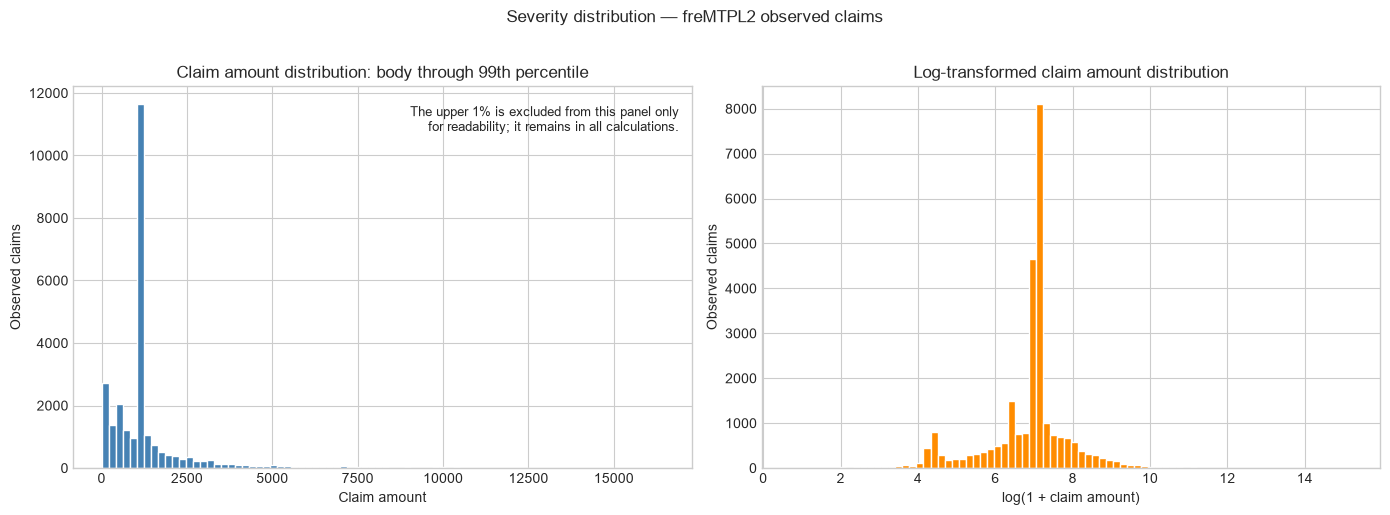

In [31]:
claim_amount_percentiles = sev["ClaimAmount"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1]
).rename("ClaimAmount")
display(claim_amount_percentiles.to_frame())

claim_amount_extremes = pd.Series(
    {
        "Claims above the 99th percentile": (sev["ClaimAmount"] > claim_amount_percentiles.loc[0.99]).sum(),
        "Claims above 100,000": (sev["ClaimAmount"] > 100_000).sum(),
        "Claims above 1,000,000": (sev["ClaimAmount"] > 1_000_000).sum(),
    },
    name="Claim count",
)
display(claim_amount_extremes.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(
    sev["ClaimAmount"],
    bins=80,
    range=(0, claim_amount_percentiles.loc[0.99]),
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("Claim amount distribution: body through 99th percentile")
axes[0].set_xlabel("Claim amount")
axes[0].set_ylabel("Observed claims")
axes[0].text(
    0.98,
    0.95,
    "The upper 1% is excluded from this panel only\nfor readability; it remains in all calculations.",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
)
axes[1].hist(
    np.log1p(sev["ClaimAmount"]),
    bins=80,
    color="darkorange",
    edgecolor="white",
)
axes[1].set_title("Log-transformed claim amount distribution")
axes[1].set_xlabel("log(1 + claim amount)")
axes[1].set_ylabel("Observed claims")
fig.suptitle("Severity distribution — freMTPL2 observed claims", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_claim_amount_distribution.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

### Claim amount distribution — observation, importance, decision

**What do we see?** Claim amounts are strongly right-skewed: the median is 1,172.00, the 99th percentile is 16,451.22, and the maximum is 4,075,400.56. There are 265 claims above the 99th percentile, including 41 above 100,000 and 3 above 1,000,000.

**Why does it matter?** A small high-cost tail can materially change total claim cost and average severity, so a linear full-range histogram would hide the distribution's main body.

**What decision could this support?** Retain extreme claims in portfolio KPIs and establish a claim-review queue for very large losses; review should investigate validity and handling, not automatically remove them.

,Policy count
ClaimNb,
0,653047
1,23571
2,1298
3,62
4,5
5,2
6,1
8,1
9,1


,Exposure years
count,677991.000000
mean,0.528743
std,0.364441
min,0.002732
1%,0.008219
5%,0.040000
25%,0.180000
50%,0.490000
75%,0.990000
95%,1.000000


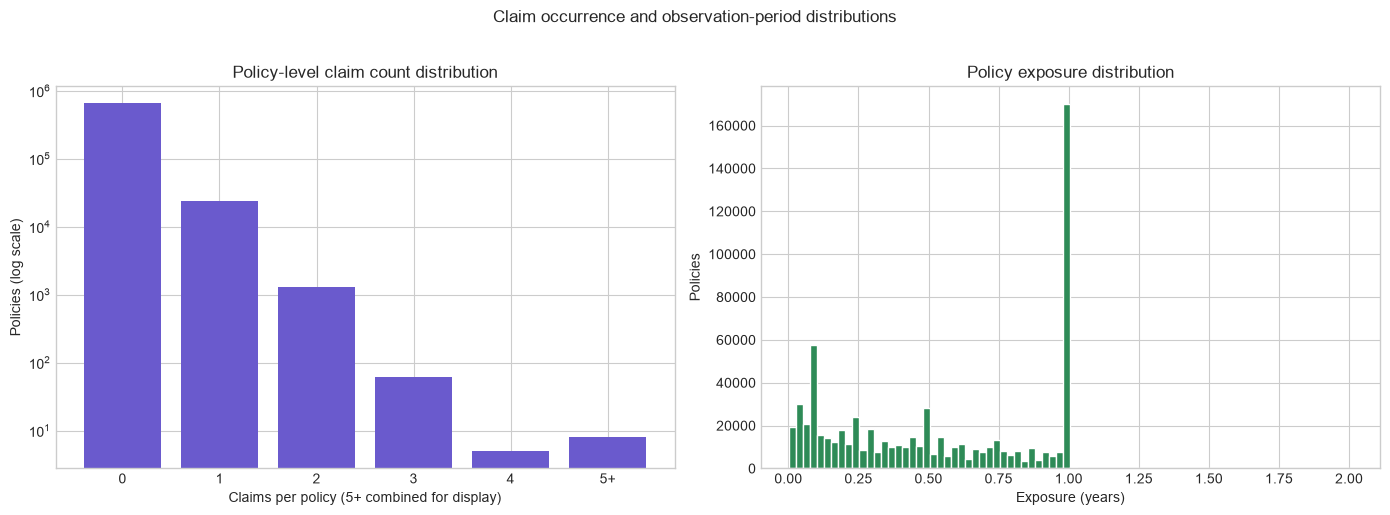

In [32]:
claim_count_distribution = freq["ClaimNb"].value_counts().sort_index()
claim_count_distribution.index = claim_count_distribution.index.astype(int)
display(claim_count_distribution.rename("Policy count").to_frame())

exposure_summary = freq["Exposure"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame(name="Exposure years")
display(exposure_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
claim_display = claim_count_distribution.loc[claim_count_distribution.index <= 4].copy()
claim_display.loc["5+"] = claim_count_distribution.loc[claim_count_distribution.index >= 5].sum()
axes[0].bar(claim_display.index.astype(str), claim_display.values, color="slateblue")
axes[0].set_yscale("log")
axes[0].set_title("Policy-level claim count distribution")
axes[0].set_xlabel("Claims per policy (5+ combined for display)")
axes[0].set_ylabel("Policies (log scale)")
axes[1].hist(freq["Exposure"], bins=80, color="seagreen", edgecolor="white")
axes[1].set_title("Policy exposure distribution")
axes[1].set_xlabel("Exposure (years)")
axes[1].set_ylabel("Policies")
fig.suptitle("Claim occurrence and observation-period distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_claim_count_and_exposure.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

### Claim count and exposure — observation, importance, decision

**What do we see?** 653,047 of 677,991 policies have zero claims and 23,571 have one; higher claim counts are rare. Exposure is not uniform: its median is 0.49 years, 75.0% of policies have less than one year of exposure, and only 24.8% have exactly one year.

**Why does it matter?** Raw claim counts and policy counts reflect how much portfolio time is observed. They cannot be interpreted as a comparable risk measure across segments with different exposure.

**What decision could this support?** Use Claim Frequency (claims divided by exposure) in monthly monitoring and require exposure volume alongside every segment-level claim-count visual.

,DrivAge,VehAge,BonusMalus
count,677991.0,677991.0,677991.0
mean,45.499092,7.044244,59.761559
std,14.137449,5.666226,15.636713
min,18.0,0.0,50.0
1%,20.0,0.0,50.0
5%,25.0,0.0,50.0
25%,34.0,2.0,50.0
50%,44.0,6.0,50.0
75%,55.0,11.0,64.0
95%,72.0,17.0,95.0


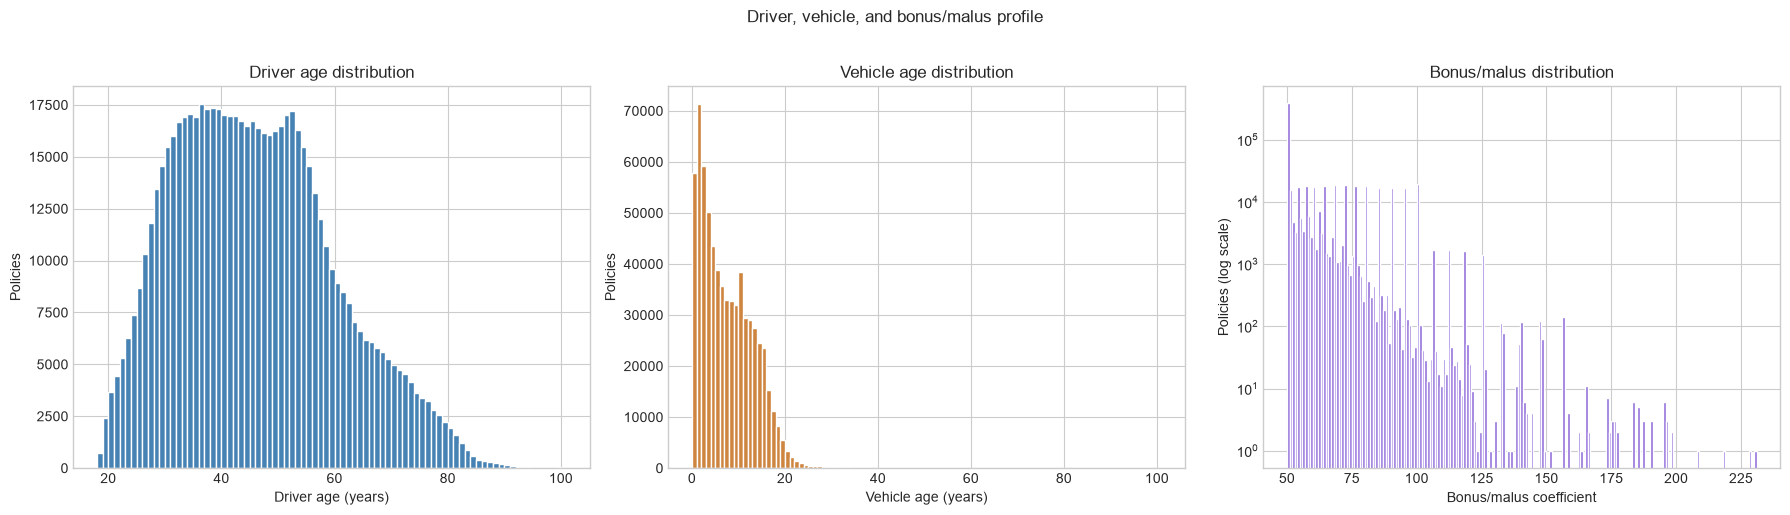

In [33]:
demographic_summary = portfolio[["DrivAge", "VehAge", "BonusMalus"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
display(demographic_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(portfolio["DrivAge"], bins=range(18, 102), color="steelblue", edgecolor="white")
axes[0].set_title("Driver age distribution")
axes[0].set_xlabel("Driver age (years)")
axes[0].set_ylabel("Policies")
axes[1].hist(portfolio["VehAge"], bins=range(0, 102), color="peru", edgecolor="white")
axes[1].set_title("Vehicle age distribution")
axes[1].set_xlabel("Vehicle age (years)")
axes[1].set_ylabel("Policies")
axes[2].hist(portfolio["BonusMalus"], bins=range(50, 232), color="mediumpurple", edgecolor="white")
axes[2].set_yscale("log")
axes[2].set_title("Bonus/malus distribution")
axes[2].set_xlabel("Bonus/malus coefficient")
axes[2].set_ylabel("Policies (log scale)")
fig.suptitle("Driver, vehicle, and bonus/malus profile", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_driver_vehicle_bonus_malus.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

### Driver, vehicle, and bonus/malus profile — observation, importance, decision

**What do we see?** The median driver age is 44 and the median vehicle age is 6. `BonusMalus` is concentrated at 50: 384,142 policies (56.7%) have that value, while only 7,794 policies have a malus above 100.

**Why does it matter?** Equal-sized quantile groups would be misleading for bonus/malus, and small malus groups require their exposure and claim volume to be shown with any apparent risk difference.

**What decision could this support?** Keep the fixed business bands from Phase 7 and monitor the Standard (100) and Malus (101+) cohorts separately, while treating observed differences as descriptive rather than causal.

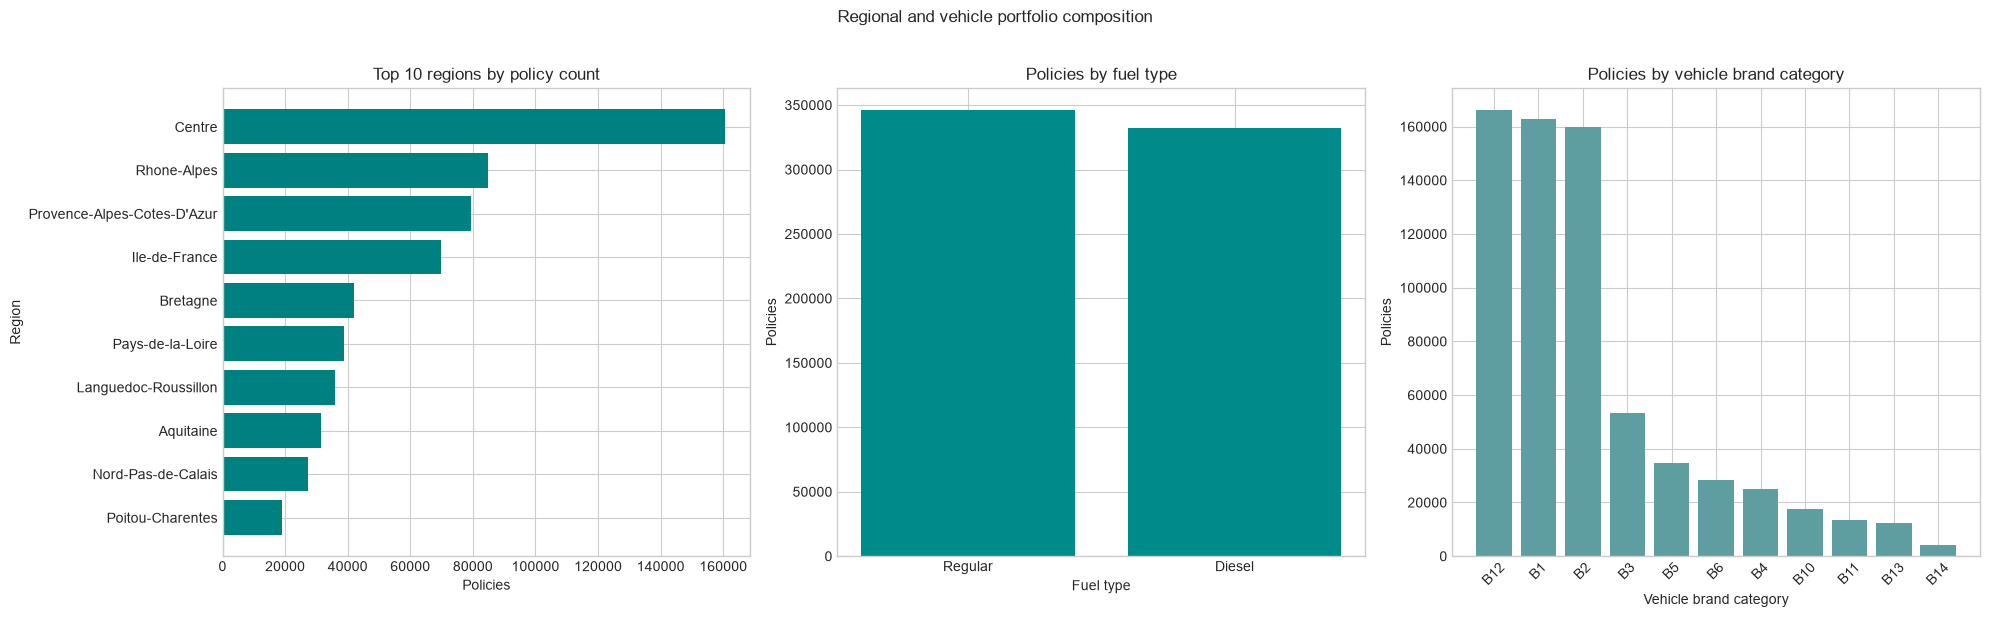

In [34]:
region_policy_count = portfolio["Region"].value_counts().sort_values(ascending=False)
fuel_policy_count = portfolio["VehGas"].value_counts().sort_values(ascending=False)
brand_policy_count = portfolio["VehBrand"].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].barh(region_policy_count.head(10).index.astype(str), region_policy_count.head(10).values, color="teal")
axes[0].invert_yaxis()
axes[0].set_title("Top 10 regions by policy count")
axes[0].set_xlabel("Policies")
axes[0].set_ylabel("Region")
axes[1].bar(fuel_policy_count.index.astype(str), fuel_policy_count.values, color="darkcyan")
axes[1].set_title("Policies by fuel type")
axes[1].set_xlabel("Fuel type")
axes[1].set_ylabel("Policies")
axes[2].bar(brand_policy_count.index.astype(str), brand_policy_count.values, color="cadetblue")
axes[2].set_title("Policies by vehicle brand category")
axes[2].set_xlabel("Vehicle brand category")
axes[2].set_ylabel("Policies")
axes[2].tick_params(axis="x", rotation=45)
fig.suptitle("Regional and vehicle portfolio composition", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_region_fuel_brand.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

### Region, fuel, and brand — observation, importance, decision

**What do we see?** Portfolio size varies markedly by region and brand. Rhone-Alpes has the highest regional frequency (0.0934), Centre has the greatest total cost (19.07 million) because it also has the largest observed exposure, and Champagne-Ardenne has the highest regional severity (6,249.98) from only 77 claims. Diesel has higher frequency than Regular (0.0788 vs 0.0692), whereas Regular has higher average severity (2,486.88 vs 2,051.65).

**Why does it matter?** A large total cost can arise from a large portfolio rather than an unusually high claim rate, while very high severity from a small claim count is less stable.

**What decision could this support?** Build region, fuel, and brand monitoring views that show frequency, severity, exposure, and claim count together; prioritize investigation of high-rate or high-severity cells only after checking their volume.

In [35]:
eda_segment_columns = [
    "DriverAgeGroup",
    "VehicleAgeGroup",
    "VehiclePowerGroup",
    "BonusMalusGroup",
    "Area",
    "Region",
    "VehGas",
    "VehBrand",
]

eda_segment_kpis = {
    column: calculate_kpis_by_segment(portfolio, column)
    for column in eda_segment_columns
}

for column, table in eda_segment_kpis.items():
    print(f"\n{column} KPI comparison")
    display(table.sort_values("ClaimFrequency", ascending=False))


DriverAgeGroup KPI comparison


,DriverAgeGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
0,Young (18-24),30196,12487.371085,2011.0,0.161043,11741344.21,5838.560025
1,Early Career (25-34),140944,64597.364437,4973.0,0.076985,9957419.91,2002.296382
2,Mid-age (35-49),252118,131223.170662,9563.0,0.072876,18265396.59,1910.006963
3,Mature (50-64),181574,102186.149449,7033.0,0.068825,13286251.41,1889.130017
4,Senior (65+),73159,47988.779831,2864.0,0.059681,6658804.38,2325.001529



VehicleAgeGroup KPI comparison


,VehicleAgeGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
2,Mid-age (6-10),171587,99003.236361,8009.0,0.080896,15805071.87,1973.413893
1,Recent (2-5),191610,101744.052776,7582.0,0.074520,15366736.33,2026.739162
0,New (0-1),129018,49465.206348,3509.0,0.070939,7485825.24,2133.321528
3,Old (11-20),177455,103123.224014,7137.0,0.069208,20818738.75,2917.015378
4,Very old (21+),8321,5147.115965,207.0,0.040217,432844.31,2091.035314



VehiclePowerGroup KPI comparison


...

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
21,Rhone-Alpes,84748,45343.547286,4233.0,0.093354,10278303.85,2428.136983
18,Picardie,7994,3574.410221,314.0,0.087847,687624.87,2189.888121
11,Ile-de-France,69789,30207.161954,2591.0,0.085774,4563221.86,1761.181729
20,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986.0,0.083430,6871024.80,2301.079973
13,Limousin,4567,2395.994542,197.0,0.082221,280285.14,1422.767208
16,Nord-Pas-de-Calais,27284,11496.974269,944.0,0.082109,1634689.72,1731.662839
0,Alsace,2200,1209.115823,92.0,0.076089,121424.99,1319.836848
8,Corse,4516,1765.935399,132.0,0.074748,464582.55,3519.564773
1,Aquitaine,31329,14322.166692,1055.0,0.073662,1916138.54,1816.245062
12,Languedoc-Roussillon,35805,14736.104177,1068.0,0.072475,2030911.08,1901.602135



VehGas KPI comparison


,VehGas,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
0,Diesel,332128,170653.973127,13450.0,0.078814,27594673.95,2051.648621
1,Regular,345863,187828.862336,12994.0,0.069180,32314542.55,2486.881834



VehBrand KPI comparison


,VehBrand,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
2,B11,13585,6887.817279,664.0,0.096402,2228920.37,3356.807786
7,B3,53393,28591.156331,2429.0,0.084956,5197982.07,2139.967917
9,B5,34752,19991.062695,1662.0,0.083137,2901047.93,1745.516203
1,B10,17707,9496.014123,765.0,0.080560,1683301.31,2200.393869
10,B6,28545,15682.623599,1252.0,0.079834,1957513.74,1563.509377
8,B4,25179,13775.496080,1099.0,0.079779,2546351.21,2316.971074
4,B13,12177,6771.442216,539.0,0.079599,1161629.56,2155.156883
0,B1,162730,95346.549578,6898.0,0.072347,14462378.14,2096.604543
6,B2,159854,94858.807101,6805.0,0.071738,18801244.90,2762.857443
3,B12,166022,64807.398718,4200.0,0.064807,8747094.58,2082.641567


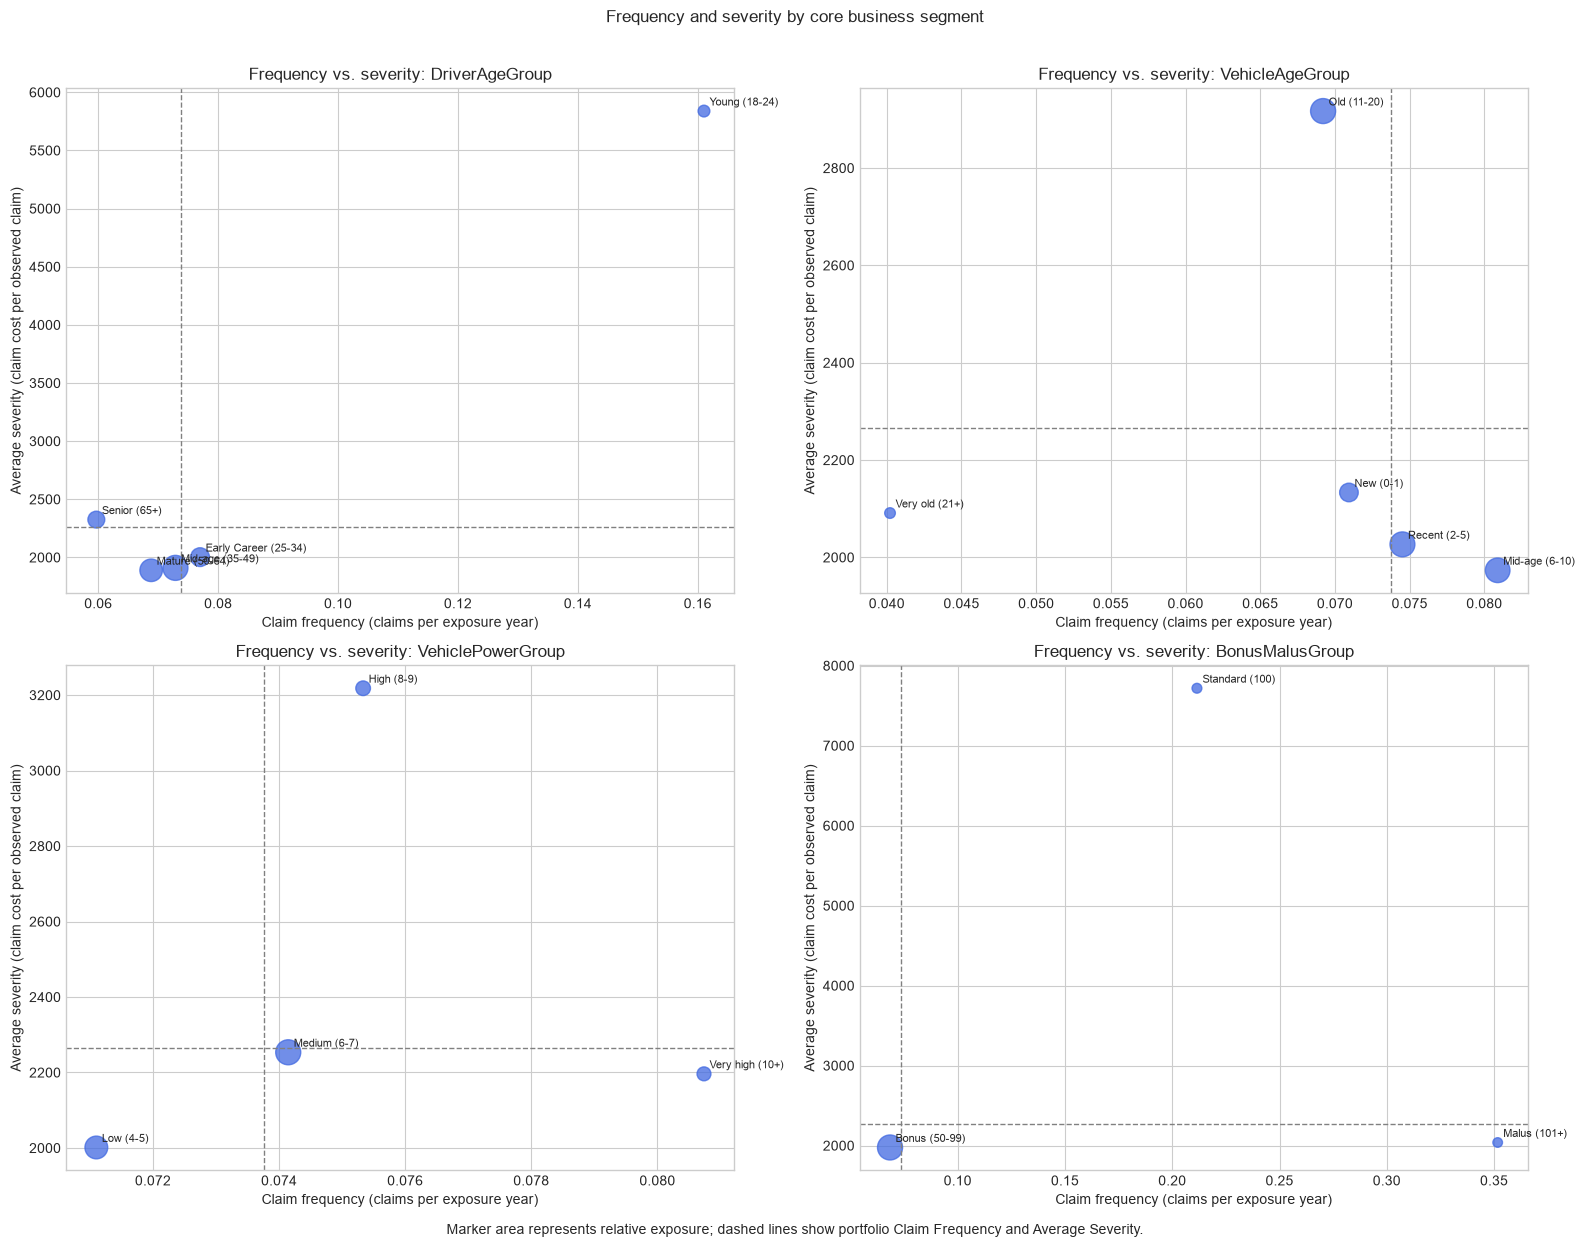

In [36]:
def plot_frequency_severity(ax, table, group_column):
    marker_size = 45 + 280 * table["Exposure"] / table["Exposure"].max()
    ax.scatter(
        table["ClaimFrequency"],
        table["AverageSeverity"],
        s=marker_size,
        color="royalblue",
        alpha=0.75,
    )
    for _, row in table.iterrows():
        ax.annotate(
            str(row[group_column]),
            (row["ClaimFrequency"], row["AverageSeverity"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax.axvline(portfolio_kpis["ClaimFrequency"], color="gray", linestyle="--", linewidth=1)
    ax.axhline(portfolio_kpis["AverageSeverity"], color="gray", linestyle="--", linewidth=1)
    ax.set_title(f"Frequency vs. severity: {group_column}")
    ax.set_xlabel("Claim frequency (claims per exposure year)")
    ax.set_ylabel("Average severity (claim cost per observed claim)")

comparison_segments = [
    "DriverAgeGroup",
    "VehicleAgeGroup",
    "VehiclePowerGroup",
    "BonusMalusGroup",
]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for axis, column in zip(axes.flat, comparison_segments):
    plot_frequency_severity(axis, eda_segment_kpis[column], column)
fig.suptitle("Frequency and severity by core business segment", y=1.01)
fig.text(
    0.5,
    -0.01,
    "Marker area represents relative exposure; dashed lines show portfolio Claim Frequency and Average Severity.",
    ha="center",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase9_frequency_vs_severity.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

### Segment KPI comparison — observation, importance, decision

**What do we see?** Frequency and severity do not move together consistently. Young drivers have both high frequency (0.1610) and high severity (5,838.56); the Standard (100) bonus/malus group has frequency 0.2115 and severity 7,717.46; the smaller Malus (101+) group has the highest frequency (0.3517) but a lower severity (2,038.16). High-power vehicles have the highest power-band severity (3,218.05), while Very high-power vehicles have the highest frequency (0.0807).

**Why does it matter?** A segment can be frequent but not especially severe, or costly but not highly frequent. Both dimensions, plus exposure and claim volume, are needed before prioritizing a segment.

**What decision could this support?** Use a frequency-versus-severity matrix for monthly review: investigate segments above one or both portfolio benchmarks, and attach exposure and claim count so management can distinguish persistent signals from small-volume variation.

## Phase 9 Learning Checkpoint

The notebook now contains the requested distributional analysis and six-KPI comparisons for driver age, vehicle age, vehicle power, bonus/malus, area, region, fuel type, and vehicle brand. The figures use log scaling or a clearly labelled readability range where appropriate, while all calculations retain the complete original data. The next phase will use this evidence to answer the eight management questions.

# 10. Answer the Eight Business Questions

This section turns the completed exploratory analysis into decision-oriented answers. Every comparison uses the Phase 8 policy-level KPIs, retains all observed claims, and describes associations in this dataset rather than causal effects.

## Q1 — What is the overall health of the insurance portfolio?

The full-portfolio view establishes the benchmark for every later segment comparison.

In [37]:
portfolio_summary = pd.DataFrame([calculate_kpis(portfolio)], index=["Overall portfolio"])
portfolio_summary

,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
Overall portfolio,677991,358482.835463,26444.0,0.073766,59909216.5,2265.512649


### KPI meaning and management interpretation

- **Policy Count (677,991):** number of distinct policies represented.
- **Exposure (358,482.84 years):** total observed insured time; it is the denominator for frequency.
- **Claim Count (26,444):** observed claims during that exposure.
- **Claim Frequency (0.07377):** 0.07377 claims per exposure year.
- **Total Claim Cost (59.91 million):** total observed cost of all Severity claim rows after policy-level aggregation.
- **Average Severity (2,265.51):** total cost per observed claim, using all 26,444 Severity rows in the denominator.

Raw Claim Count alone is misleading because a large or long-observed segment naturally produces more claims. Claim Frequency controls for observed exposure, so management should interpret each segment's frequency, severity, exposure, and claim count together.

## Q2 — Which regions generate the greatest claim burden?

Regions are compared using all six KPIs rather than raw counts alone.

In [38]:
region_kpis = calculate_kpis_by_segment(portfolio, "Region")
region_kpis["ExposureShare"] = region_kpis["Exposure"] / portfolio_kpis["Exposure"]
region_kpis["CostShare"] = region_kpis["TotalClaimCost"] / portfolio_kpis["TotalClaimCost"]
region_kpis = region_kpis.sort_values("ClaimFrequency", ascending=False).reset_index(drop=True)
display(region_kpis)
region_attention = region_kpis.loc[region_kpis["Region"] == "Rhone-Alpes"].copy()
region_attention

,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity,ExposureShare,CostShare
0,Rhone-Alpes,84748,45343.547286,4233.0,0.093354,10278303.85,2428.136983,0.126487,0.171565
1,Picardie,7994,3574.410221,314.0,0.087847,687624.87,2189.888121,0.009971,0.011478
2,Ile-de-France,69789,30207.161954,2591.0,0.085774,4563221.86,1761.181729,0.084264,0.076169
3,Provence-Alpes-Cotes-D'Azur,79315,35790.321015,2986.0,0.083430,6871024.80,2301.079973,0.099838,0.114691
4,Limousin,4567,2395.994542,197.0,0.082221,280285.14,1422.767208,0.006684,0.004678
5,Nord-Pas-de-Calais,27284,11496.974269,944.0,0.082109,1634689.72,1731.662839,0.032071,0.027286
6,Alsace,2200,1209.115823,92.0,0.076089,121424.99,1319.836848,0.003373,0.002027
7,Corse,4516,1765.935399,132.0,0.074748,464582.55,3519.564773,0.004926,0.007755
8,Aquitaine,31329,14322.166692,1055.0,0.073662,1916138.54,1816.245062,0.039952,0.031984
9,Languedoc-Roussillon,35805,14736.104177,1068.0,0.072475,2030911.08,1901.602135,0.041107,0.033900


,Region,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity,ExposureShare,CostShare
0,Rhone-Alpes,84748,45343.547286,4233.0,0.093354,10278303.85,2428.136983,0.126487,0.171565


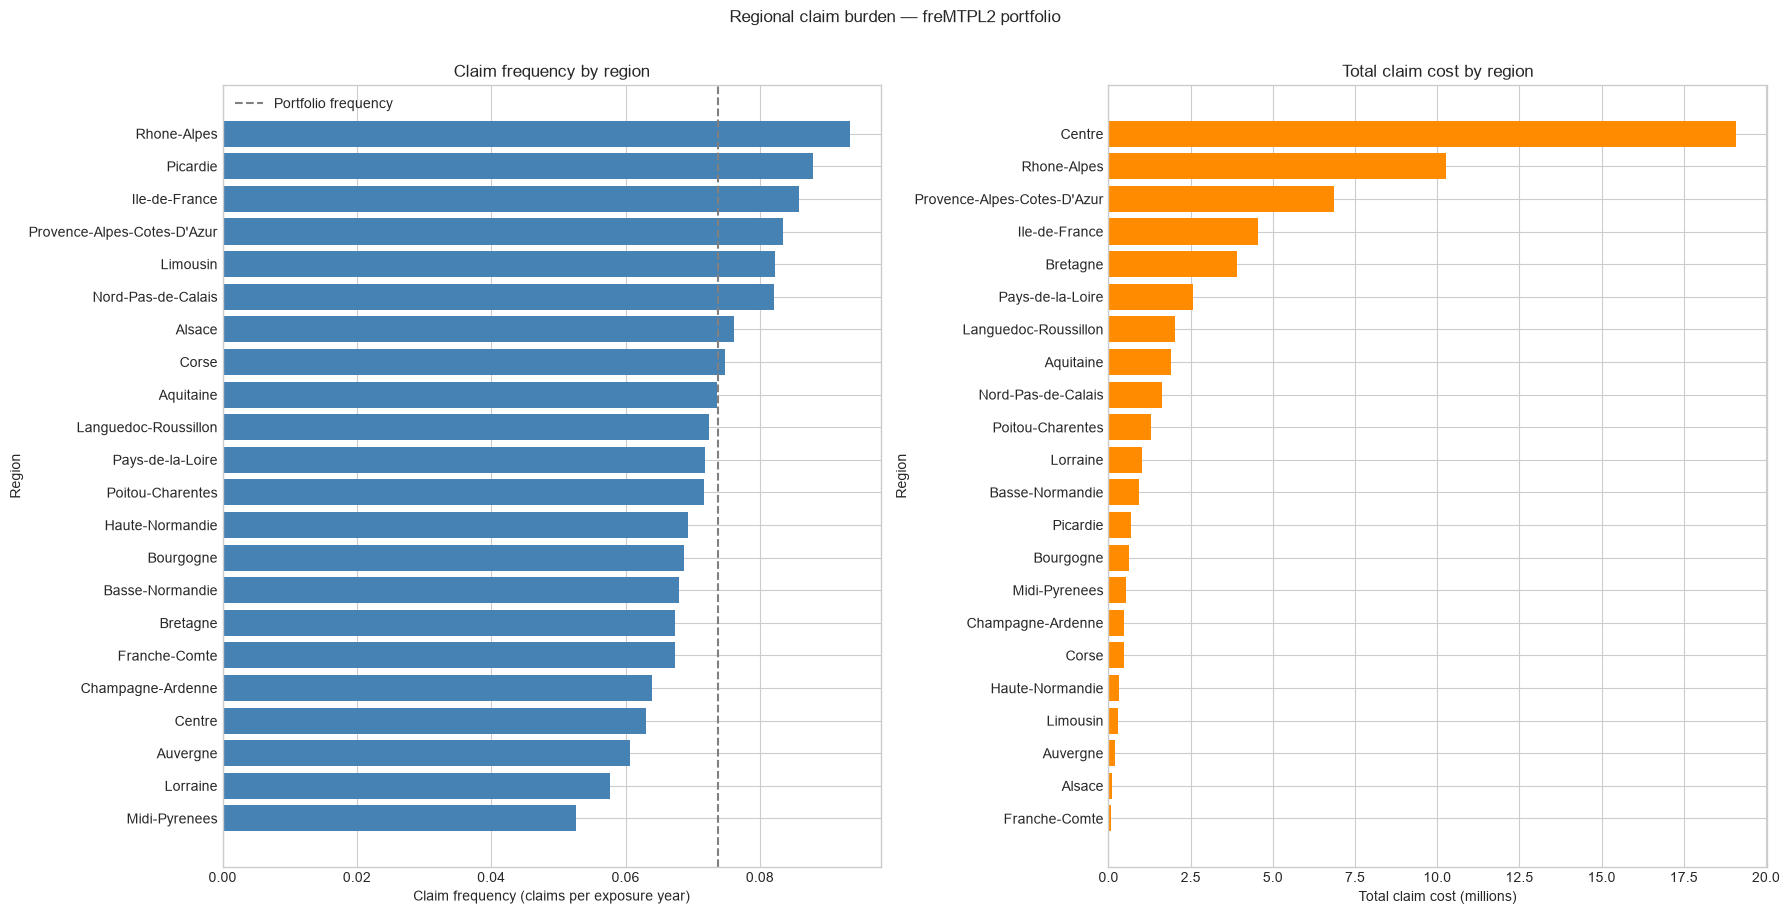

In [39]:
region_by_frequency = region_kpis.sort_values("ClaimFrequency")
region_by_cost = region_kpis.sort_values("TotalClaimCost")
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
axes[0].barh(region_by_frequency["Region"].astype(str), region_by_frequency["ClaimFrequency"], color="steelblue")
axes[0].axvline(portfolio_kpis["ClaimFrequency"], color="gray", linestyle="--", label="Portfolio frequency")
axes[0].set_title("Claim frequency by region")
axes[0].set_xlabel("Claim frequency (claims per exposure year)")
axes[0].set_ylabel("Region")
axes[0].legend()
axes[1].barh(region_by_cost["Region"].astype(str), region_by_cost["TotalClaimCost"] / 1_000_000, color="darkorange")
axes[1].set_title("Total claim cost by region")
axes[1].set_xlabel("Total claim cost (millions)")
axes[1].set_ylabel("Region")
fig.suptitle("Regional claim burden — freMTPL2 portfolio", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase10_region_claim_burden.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

**Answer.** Rhone-Alpes deserves attention because it combines the highest observed Claim Frequency (0.0934, versus 0.07377 for the portfolio) with the second-highest Total Claim Cost (10.28 million) and substantial Exposure (45,343.55 years). This uses frequency and cost together, not Claim Count alone. Centre has the greatest total cost (19.07 million), but also the largest exposure and a below-portfolio frequency (0.0600); its above-benchmark severity (2,945.92) should be monitored separately.

## Q3 — Which driver and vehicle segments show different claim patterns?

The tables below apply the six core KPIs independently to the requested driver and vehicle dimensions.

In [40]:
q3_segment_columns = ["DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "VehGas", "BonusMalusGroup"]
q3_segment_summaries = {
    column: calculate_kpis_by_segment(portfolio, column).sort_values("ClaimFrequency", ascending=False)
    for column in q3_segment_columns
}
for column, table in q3_segment_summaries.items():
    print(f"\n{column} summary")
    display(table)


DriverAgeGroup summary


,DriverAgeGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
0,Young (18-24),30196,12487.371085,2011.0,0.161043,11741344.21,5838.560025
1,Early Career (25-34),140944,64597.364437,4973.0,0.076985,9957419.91,2002.296382
2,Mid-age (35-49),252118,131223.170662,9563.0,0.072876,18265396.59,1910.006963
3,Mature (50-64),181574,102186.149449,7033.0,0.068825,13286251.41,1889.130017
4,Senior (65+),73159,47988.779831,2864.0,0.059681,6658804.38,2325.001529



VehicleAgeGroup summary


,VehicleAgeGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
2,Mid-age (6-10),171587,99003.236361,8009.0,0.080896,15805071.87,1973.413893
1,Recent (2-5),191610,101744.052776,7582.0,0.074520,15366736.33,2026.739162
0,New (0-1),129018,49465.206348,3509.0,0.070939,7485825.24,2133.321528
3,Old (11-20),177455,103123.224014,7137.0,0.069208,20818738.75,2917.015378
4,Very old (21+),8321,5147.115965,207.0,0.040217,432844.31,2091.035314



VehiclePowerGroup summary


,VehiclePowerGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
3,Very high (10+),66424,31744.372505,2563.0,0.080739,5629323.78,2196.380718
2,High (8-9),77038,38031.059961,2865.0,0.075333,9219718.16,3218.051714
1,Medium (6-7),294370,160468.876873,11898.0,0.074145,26812343.99,2253.516893
0,Low (4-5),240159,128238.526125,9118.0,0.071102,18247830.57,2001.297496



VehGas summary


,VehGas,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
0,Diesel,332128,170653.973127,13450.0,0.078814,27594673.95,2051.648621
1,Regular,345863,187828.862336,12994.0,0.069180,32314542.55,2486.881834



BonusMalusGroup summary


,BonusMalusGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity
2,Malus (101+),7794,3571.319003,1256.0,0.351691,2559929.56,2038.160478
1,Standard (100),19530,6240.873357,1320.0,0.211509,10187048.58,7717.461045
0,Bonus (50-99),650667,348670.643104,23868.0,0.068454,47162238.36,1975.961051


**Answer.** Several segments appear materially different in this dataset. Young drivers show higher observed frequency (0.1610) and severity (5,838.56) than the portfolio. Malus (101+) shows the highest frequency (0.3517), while Standard (100) shows the highest severity (7,717.46); both should be read with their lower exposure and claim volumes. High-power vehicles show the highest power-band severity (3,218.05), while Very high-power vehicles show the highest frequency (0.0807). Diesel is associated with higher observed frequency than Regular fuel (0.0788 versus 0.0692), whereas Regular is associated with higher severity (2,486.88 versus 2,051.65). These are descriptive associations, not evidence that any attribute causes claims.

## Q4 — Are frequent-claim segments also expensive-claim segments?

Driver age is the focal business segmentation. Dashed lines are portfolio benchmarks; quadrants are descriptive labels, not a formal underwriting risk score.

,DriverAgeGroup,PolicyCount,Exposure,ClaimCount,ClaimFrequency,TotalClaimCost,AverageSeverity,FrequencyBenchmark,SeverityBenchmark,DescriptiveQuadrant
0,Young (18-24),30196,12487.371085,2011.0,0.161043,11741344.21,5838.560025,High frequency,High severity,High frequency / High severity
1,Early Career (25-34),140944,64597.364437,4973.0,0.076985,9957419.91,2002.296382,High frequency,Low severity,High frequency / Low severity
2,Mid-age (35-49),252118,131223.170662,9563.0,0.072876,18265396.59,1910.006963,Low frequency,Low severity,Low frequency / Low severity
3,Mature (50-64),181574,102186.149449,7033.0,0.068825,13286251.41,1889.130017,Low frequency,Low severity,Low frequency / Low severity
4,Senior (65+),73159,47988.779831,2864.0,0.059681,6658804.38,2325.001529,Low frequency,High severity,Low frequency / High severity


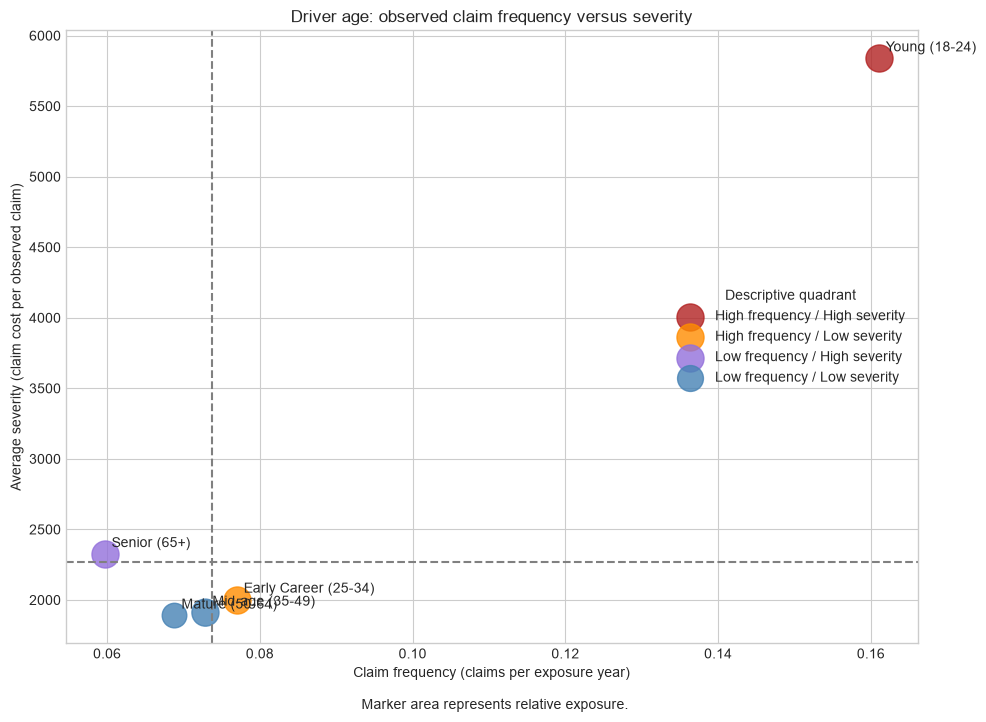

In [41]:
frequency_severity_segments = q3_segment_summaries["DriverAgeGroup"].copy()
frequency_severity_segments["FrequencyBenchmark"] = np.where(frequency_severity_segments["ClaimFrequency"] >= portfolio_kpis["ClaimFrequency"], "High frequency", "Low frequency")
frequency_severity_segments["SeverityBenchmark"] = np.where(frequency_severity_segments["AverageSeverity"] >= portfolio_kpis["AverageSeverity"], "High severity", "Low severity")
frequency_severity_segments["DescriptiveQuadrant"] = frequency_severity_segments["FrequencyBenchmark"] + " / " + frequency_severity_segments["SeverityBenchmark"]
display(frequency_severity_segments)
quadrant_colors = {"High frequency / High severity": "firebrick", "High frequency / Low severity": "darkorange", "Low frequency / High severity": "mediumpurple", "Low frequency / Low severity": "steelblue"}
fig, ax = plt.subplots(figsize=(10, 7))
for quadrant, subset in frequency_severity_segments.groupby("DescriptiveQuadrant"):
    ax.scatter(subset["ClaimFrequency"], subset["AverageSeverity"], s=80 + 300 * subset["Exposure"] / subset["Exposure"].max(), color=quadrant_colors[quadrant], alpha=0.8, label=quadrant)
    for _, row in subset.iterrows():
        ax.annotate(str(row["DriverAgeGroup"]), (row["ClaimFrequency"], row["AverageSeverity"]), xytext=(5, 5), textcoords="offset points")
ax.axvline(portfolio_kpis["ClaimFrequency"], color="gray", linestyle="--")
ax.axhline(portfolio_kpis["AverageSeverity"], color="gray", linestyle="--")
ax.set_title("Driver age: observed claim frequency versus severity")
ax.set_xlabel("Claim frequency (claims per exposure year)")
ax.set_ylabel("Average severity (claim cost per observed claim)")
ax.legend(title="Descriptive quadrant")
fig.text(0.5, -0.02, "Marker area represents relative exposure.", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase10_driver_age_frequency_severity.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

**Answer.** Frequent segments are not automatically expensive segments. Young drivers fall in the high-frequency/high-severity descriptive quadrant, while Senior is below the frequency benchmark but slightly above the severity benchmark. Early Career is above the frequency benchmark but below the severity benchmark. The pattern supports joint monitoring of frequency and severity rather than ranking groups using one metric.

## Q5 — Is claim cost concentrated in a small number of claims or policies?

Pareto analysis sorts observed claim costs and policy-level total costs from largest to smallest, then calculates the cumulative percentage of total cost.

In [42]:
def build_pareto(values: pd.Series, value_name: str) -> pd.DataFrame:
    ordered = values.sort_values(ascending=False).reset_index(drop=True)
    pareto = pd.DataFrame({value_name: ordered})
    pareto["CumulativeCost"] = pareto[value_name].cumsum()
    pareto["CumulativeCostPct"] = pareto["CumulativeCost"] / pareto[value_name].sum()
    pareto["CumulativeItemPct"] = (pareto.index + 1) / len(pareto)
    return pareto

def concentration_at_thresholds(pareto: pd.DataFrame) -> pd.DataFrame:
    records = []
    for threshold in [0.01, 0.05, 0.10]:
        position = int(np.ceil(len(pareto) * threshold)) - 1
        records.append({"Top share of items": threshold, "Items included": position + 1, "Share of total cost": pareto.iloc[position]["CumulativeCostPct"]})
    return pd.DataFrame(records)

claim_pareto = build_pareto(sev["ClaimAmount"], "ClaimAmount")
policy_pareto = build_pareto(portfolio.loc[portfolio["TotalClaimAmount"] > 0, "TotalClaimAmount"], "TotalClaimAmount")
claim_concentration = concentration_at_thresholds(claim_pareto)
policy_concentration = concentration_at_thresholds(policy_pareto)
display(claim_concentration)
policy_concentration

,Top share of items,Items included,Share of total cost
0,0.01,265,0.380140
1,0.05,1323,0.520931
2,0.10,2645,0.599261


,Top share of items,Items included,Share of total cost
0,0.01,250,0.378911
1,0.05,1248,0.523067
2,0.10,2495,0.602092


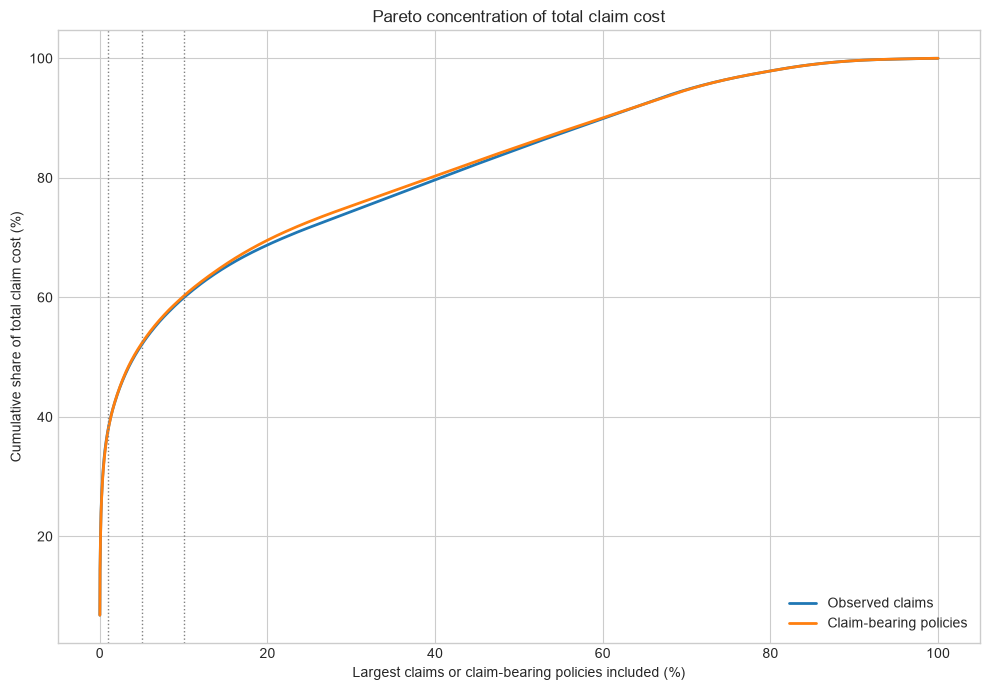

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(claim_pareto["CumulativeItemPct"] * 100, claim_pareto["CumulativeCostPct"] * 100, label="Observed claims", linewidth=2)
ax.plot(policy_pareto["CumulativeItemPct"] * 100, policy_pareto["CumulativeCostPct"] * 100, label="Claim-bearing policies", linewidth=2)
for threshold in [1, 5, 10]:
    ax.axvline(threshold, color="gray", linestyle=":", linewidth=1)
ax.set_title("Pareto concentration of total claim cost")
ax.set_xlabel("Largest claims or claim-bearing policies included (%)")
ax.set_ylabel("Cumulative share of total claim cost (%)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "phase10_claim_cost_pareto.png", dpi=160, bbox_inches="tight")
display(fig)
plt.close(fig)

**Answer.** Cost is concentrated. The largest 1%, 5%, and 10% of the 26,444 observed claims contribute 38.01%, 52.09%, and 59.93% of total claim cost. At the policy level, using the 24,944 claim-bearing policies as the meaningful Pareto denominator, the largest 1%, 5%, and 10% contribute 37.89%, 52.31%, and 60.21%. Zero-cost policies are excluded from `policy_pareto` because they add no cost; including all 677,991 policies would make the top 5% mechanically contain all claim-bearing policies and obscure the concentration pattern.

## Q6 — What unusual claims or segments should management investigate?

The investigation threshold is the 99.5th claim-amount percentile. It identifies unusually large observations for review without declaring them invalid or deleting them.

In [44]:
claim_detail = sev.merge(
    portfolio[["IDpol", "Region", "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup", "DrivAge", "VehAge", "VehPower", "BonusMalus"]],
    on="IDpol", how="left", validate="many_to_one",
)
extreme_claim_threshold = sev["ClaimAmount"].quantile(0.995)
unusual_claims_review = claim_detail.loc[claim_detail["ClaimAmount"] >= extreme_claim_threshold].sort_values("ClaimAmount", ascending=False).reset_index(drop=True)
unusual_claims_review["ExtremeClaimRank"] = unusual_claims_review.index + 1
unusual_claims_review["ShareOfPortfolioCost"] = unusual_claims_review["ClaimAmount"] / sev["ClaimAmount"].sum()
unusual_claims_summary = pd.Series({"99.5th percentile threshold": extreme_claim_threshold, "Extreme claims identified": len(unusual_claims_review), "Extreme claim cost": unusual_claims_review["ClaimAmount"].sum(), "Extreme claim cost share": unusual_claims_review["ClaimAmount"].sum() / sev["ClaimAmount"].sum()}, name="Unusual claim review")
display(unusual_claims_summary.to_frame())
unusual_claims_review.head(20)

,Unusual claim review
99.5th percentile threshold,3.437696e+04
Extreme claims identified,1.330000e+02
Extreme claim cost,1.974318e+07
Extreme claim cost share,3.295516e-01


,IDpol,ClaimAmount,Region,DriverAgeGroup,VehicleAgeGroup,VehiclePowerGroup,BonusMalusGroup,DrivAge,VehAge,VehPower,BonusMalus,ExtremeClaimRank,ShareOfPortfolioCost
0,1120377,4075400.56,Centre,Young (18-24),Old (11-20),High (8-9),Standard (100),19,13,9,100,1,0.068026
1,110846,1403057.40,Centre,Young (18-24),Old (11-20),Medium (6-7),Standard (100),20,13,6,100,2,0.023420
2,2141337,1301172.60,Rhone-Alpes,Young (18-24),Old (11-20),Low (4-5),Standard (100),18,14,4,100,3,0.021719
3,3122016,774411.50,Rhone-Alpes,Mid-age (35-49),Mid-age (6-10),Medium (6-7),Bonus (50-99),40,7,7,63,4,0.012926
4,2008127,390742.27,Rhone-Alpes,Mature (50-64),Recent (2-5),Low (4-5),Bonus (50-99),57,2,4,50,5,0.006522
5,3025890,369131.88,Champagne-Ardenne,Mid-age (35-49),New (0-1),Medium (6-7),Bonus (50-99),36,1,7,50,6,0.006162
6,1117644,307096.42,Bretagne,Young (18-24),New (0-1),Medium (6-7),Bonus (50-99),21,1,7,90,7,0.005126
7,158309,301635.49,Centre,Mid-age (35-49),Recent (2-5),Medium (6-7),Bonus (50-99),46,3,6,50,8,0.005035
8,3075820,287423.00,Provence-Alpes-Cotes-D'Azur,Senior (65+),Old (11-20),Medium (6-7),Bonus (50-99),78,18,7,50,9,0.004798
9,3150210,281897.49,Centre,Mature (50-64),Recent (2-5),Medium (6-7),Bonus (50-99),61,4,6,54,10,0.004705


In [45]:
def summarize_extreme_claims(group_column: str) -> pd.DataFrame:
    all_claims = claim_detail.groupby(group_column, observed=True).agg(AllClaims=("ClaimAmount", "size"), AllCost=("ClaimAmount", "sum"))
    extreme_claims = unusual_claims_review.groupby(group_column, observed=True).agg(ExtremeClaims=("ClaimAmount", "size"), ExtremeCost=("ClaimAmount", "sum"))
    comparison = all_claims.join(extreme_claims, how="left").fillna(0).reset_index()
    comparison["ExtremeClaimShare"] = comparison["ExtremeClaims"] / comparison["AllClaims"]
    comparison["ExtremeCostShare"] = comparison["ExtremeCost"] / comparison["AllCost"]
    return comparison.sort_values("ExtremeCost", ascending=False)

unusual_claims_by_segment = {column: summarize_extreme_claims(column) for column in ["Region", "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup"]}
for column, table in unusual_claims_by_segment.items():
    print(f"\nExtreme-claim comparison: {column}")
    display(table)


Extreme-claim comparison: Region


,Region,AllClaims,AllCost,ExtremeClaims,ExtremeCost,ExtremeClaimShare,ExtremeCostShare
6,Centre,6475,19074802.36,46.0,9922912.00,0.007104,0.520210
21,Rhone-Alpes,4233,10278303.85,20.0,3872803.94,0.004725,0.376794
20,Provence-Alpes-Cotes-D'Azur,2986,6871024.80,16.0,1483191.95,0.005358,0.215862
5,Bretagne,1871,3901051.25,10.0,1090570.20,0.005345,0.279558
11,Ile-de-France,2591,4563221.86,8.0,734718.03,0.003088,0.161009
7,Champagne-Ardenne,77,481248.34,1.0,369131.88,0.012987,0.767030
17,Pays-de-la-Loire,1576,2570964.93,7.0,329919.11,0.004442,0.128325
3,Basse-Normandie,452,929847.31,5.0,322999.53,0.011062,0.347368
1,Aquitaine,1055,1916138.54,4.0,294168.98,0.003791,0.153522
14,Lorraine,468,1034301.30,2.0,267183.60,0.004274,0.258323



Extreme-claim comparison: DriverAgeGroup


,DriverAgeGroup,AllClaims,AllCost,ExtremeClaims,ExtremeCost,ExtremeClaimShare,ExtremeCostShare
0,Young (18-24),2011,11741344.21,19,8411128.70,0.009448,0.716368
2,Mid-age (35-49),9563,18265396.59,39,4020032.48,0.004078,0.220090
3,Mature (50-64),7033,13286251.41,34,2706837.68,0.004834,0.203732
1,Early Career (25-34),4973,9957419.91,23,2403008.93,0.004625,0.241328
4,Senior (65+),2864,6658804.38,18,2202168.26,0.006285,0.330715



Extreme-claim comparison: VehicleAgeGroup


,VehicleAgeGroup,AllClaims,AllCost,ExtremeClaims,ExtremeCost,ExtremeClaimShare,ExtremeCostShare
3,Old (11-20),7137,20818738.75,41,10686640.71,0.005745,0.513318
2,Mid-age (6-10),8009,15805071.87,38,3793592.40,0.004745,0.240024
1,Recent (2-5),7582,15366736.33,36,3408555.78,0.004748,0.221814
0,New (0-1),3509,7485825.24,17,1671887.16,0.004845,0.223340
4,Very old (21+),207,432844.31,1,182500.00,0.004831,0.421630



Extreme-claim comparison: VehiclePowerGroup


,VehiclePowerGroup,AllClaims,AllCost,ExtremeClaims,ExtremeCost,ExtremeClaimShare,ExtremeCostShare
1,Medium (6-7),11898,26812343.99,75,8951873.86,0.006304,0.333871
2,High (8-9),2865,9219718.16,10,4699675.11,0.003490,0.509742
0,Low (4-5),9118,18247830.57,33,4563077.54,0.003619,0.250061
3,Very high (10+),2563,5629323.78,15,1528549.54,0.005853,0.271533



Extreme-claim comparison: BonusMalusGroup


,BonusMalusGroup,AllClaims,AllCost,ExtremeClaims,ExtremeCost,ExtremeClaimShare,ExtremeCostShare
0,Bonus (50-99),23868,47162238.36,108,11125700.39,0.004525,0.235903
1,Standard (100),1320,10187048.58,16,7950859.88,0.012121,0.780487
2,Malus (101+),1256,2559929.56,9,666615.78,0.007166,0.260404


**Answer.** The 99.5th percentile threshold is 34,376.96. It identifies 133 claims (0.5% of observed claims) with 19.74 million of cost, or 32.96% of portfolio claim cost. Centre contains 46 of these claims and 9.92 million of their cost; the extreme claims account for 52.02% of Centre's total claim cost. Young drivers contribute 19 extreme claims but 8.41 million of cost, equal to 71.64% of their segment's cost. The Standard (100) bonus/malus group has 16 extreme claims accounting for 78.05% of its segment cost. These combinations merit claim-file and process review, but the data provides no evidence that they are invalid or that the displayed attributes caused the losses.

## Q7 — What should management monitor every month?

The future Tableau dashboard should focus on the following decision-useful components.

| Dashboard component | Why it is included | Decision it supports |
|---|---|---|
| KPI cards: Policy Count, Exposure, Claim Count, Claim Frequency, Total Claim Cost, Average Severity | Establishes current portfolio scale, observed claim activity, and cost level. | Detect broad shifts before investigating a segment. |
| Region comparison | Separates high-rate regions from high-volume cost regions. | Prioritize regional operational review. |
| Frequency versus severity matrix | Shows whether a segment is high on one or both dimensions. | Select segments for monitoring without reducing them to claim counts. |
| Driver and vehicle segment KPI table | Makes exposure, frequency, severity, and total cost available together. | Compare population segments consistently. |
| Pareto curve and high-cost claim list | Makes tail-cost concentration visible. | Trigger large-loss review and reserve/claims-process discussion. |

All dashboard filters should retain exposure and claim-volume context. Loss Ratio must remain absent because written premium is not available.

## Q8 — What are the three data-driven recommendations?

### Recommendation 1 — Monitor the Young driver cohort
**Evidence:** Young drivers have 12,487.37 exposure years, 2,011 claims, frequency of 0.1610, and average severity of 5,838.56; both measures are above the portfolio benchmarks.

**Action:** Add this cohort to the monthly frequency-versus-severity review and investigate claims-process or event-pattern explanations before proposing any intervention.

**KPI:** Track Claim Frequency, Average Severity, Exposure, and Claim Count for `Young (18-24)`.

### Recommendation 2 — Review Rhone-Alpes as a high-frequency, material-cost region
**Evidence:** Rhone-Alpes has the portfolio's highest frequency (0.0934), 45,343.55 exposure years, and the second-highest total claim cost (10.28 million).

**Action:** Include Rhone-Alpes in the regional monthly review and compare its claim mix and operational handling with portfolio benchmarks.

**KPI:** Track regional Claim Frequency, Total Claim Cost, Average Severity, Exposure, and Claim Count.

### Recommendation 3 — Establish a high-cost claim review queue
**Evidence:** The top 1% of claims contributes 38.01% of total cost, and the 133 claims at or above the 99.5th percentile contribute 32.96%.

**Action:** Review high-cost claims for validity, reserving, claims handling, and recurring operational themes; retain them in reporting unless invalidity is evidenced.

**KPI:** Track the top-1% cost share, count and cost of claims above the 99.5th percentile, and Average Severity.

## Phase 10 Learning Checkpoint

The eight management questions are now answered with named, reproducible outputs: `portfolio_summary`, `region_kpis`, the Q3 segment summary tables, `frequency_severity_segments`, `claim_pareto`, `policy_pareto`, and `unusual_claims_review`. The next phase can use this validated policy-level structure to create Tableau-ready data.

# 11. Prepare Tableau-Ready Data

Python owns documented preparation and validation; Tableau will use these exported tables for analysis, visualisation, and interaction. The primary export is at policy grain: **one row = one policy**. A small supplementary claim-level export is included only because Pareto and high-cost-claim views require individual observed claim rows.

In [46]:
TABLEAU_PORTFOLIO_COLUMNS = [
    "IDpol", "Exposure", "ClaimNb", "VehPower", "VehAge", "DrivAge",
    "BonusMalus", "VehBrand", "VehGas", "Area", "Density", "Region",
    "TotalClaimAmount", "SeverityClaimCount", "AverageClaimAmount", "MaxClaimAmount",
    "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup",
]

tableau_portfolio = portfolio.loc[:, TABLEAU_PORTFOLIO_COLUMNS].copy()
tableau_portfolio["IDpol"] = tableau_portfolio["IDpol"].astype("string")
for column in ["VehBrand", "VehGas", "Area", "Region", "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup"]:
    tableau_portfolio[column] = tableau_portfolio[column].astype("string")
tableau_portfolio["ClaimNb"] = tableau_portfolio["ClaimNb"].astype("int64")
tableau_portfolio["SeverityClaimCount"] = tableau_portfolio["SeverityClaimCount"].astype("int64")

tableau_claims = claim_detail.merge(
    portfolio[["IDpol", "VehBrand", "VehGas", "Area"]],
    on="IDpol",
    how="left",
    validate="many_to_one",
)
tableau_claims["ClaimRowID"] = np.arange(1, len(tableau_claims) + 1)
tableau_claims = tableau_claims.sort_values("ClaimAmount", ascending=False, kind="mergesort").reset_index(drop=True)
tableau_claims["ClaimAmountRank"] = np.arange(1, len(tableau_claims) + 1)
tableau_claims["CumulativeClaimCost"] = tableau_claims["ClaimAmount"].cumsum()
tableau_claims["CumulativeClaimCostPct"] = tableau_claims["CumulativeClaimCost"] / tableau_claims["ClaimAmount"].sum()
tableau_claims["CumulativeClaimPct"] = tableau_claims["ClaimAmountRank"] / len(tableau_claims)
tableau_claims["IsExtremeClaim"] = tableau_claims["ClaimAmount"] >= extreme_claim_threshold
TABLEAU_CLAIM_COLUMNS = [
    "ClaimRowID", "IDpol", "ClaimAmount", "ClaimAmountRank", "CumulativeClaimCost",
    "CumulativeClaimCostPct", "CumulativeClaimPct", "IsExtremeClaim", "Region",
    "DrivAge", "VehAge", "VehPower", "BonusMalus", "VehBrand", "VehGas", "Area",
    "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup",
]
tableau_claims = tableau_claims.loc[:, TABLEAU_CLAIM_COLUMNS].copy()
tableau_claims["IDpol"] = tableau_claims["IDpol"].astype("string")
for column in ["Region", "VehBrand", "VehGas", "Area", "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup"]:
    tableau_claims[column] = tableau_claims[column].astype("string")

tableau_export_schema = pd.DataFrame(
    [
        ["tableau_portfolio.csv", "One row = one policy", len(tableau_portfolio), len(tableau_portfolio.columns), "Primary Tableau source"],
        ["tableau_claims.csv", "One row = one observed Severity claim", len(tableau_claims), len(tableau_claims.columns), "Pareto and high-cost claim views"],
    ],
    columns=["File", "Grain", "Rows", "Columns", "Purpose"],
)
tableau_export_schema

,File,Grain,Rows,Columns,Purpose
0,tableau_portfolio.csv,One row = one policy,677991,20,Primary Tableau source
1,tableau_claims.csv,One row = one observed Severity claim,26444,20,Pareto and high-cost claim views


### Export design decisions

`tableau_portfolio.csv` contains exactly one row for each policy and includes original policy fields, aggregated Severity fields, and the four business-friendly segments. It is sufficient for KPI cards, Region and segment comparisons, and filters.

`tableau_claims.csv` is the only supplementary table. It is needed because one policy can have several observed Severity rows and a policy-level table cannot support a claim-level Pareto curve or high-cost claim list. `ClaimRowID` is a technical key generated from the source Severity row order, not an insurer-issued claim identifier. No pre-aggregated Region or Pareto file is exported because Tableau can calculate those views from these two clear grains.

In [47]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(exist_ok=True)
portfolio_export_path = PROCESSED_DIR / "tableau_portfolio.csv"
claims_export_path = PROCESSED_DIR / "tableau_claims.csv"

tableau_portfolio.to_csv(portfolio_export_path, index=False, encoding="utf-8", float_format="%.6f")
tableau_claims.to_csv(claims_export_path, index=False, encoding="utf-8", float_format="%.6f")

pd.DataFrame(
    {
        "File": [portfolio_export_path.name, claims_export_path.name],
        "Bytes written": [portfolio_export_path.stat().st_size, claims_export_path.stat().st_size],
    }
)

,File,Bytes written
0,tableau_portfolio.csv,88081689
1,tableau_claims.csv,4323021


In [48]:
portfolio_text_columns = ["IDpol", "VehBrand", "VehGas", "Area", "Region", "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup"]
claims_text_columns = ["IDpol", "Region", "VehBrand", "VehGas", "Area", "DriverAgeGroup", "VehicleAgeGroup", "VehiclePowerGroup", "BonusMalusGroup"]
portfolio_reloaded = pd.read_csv(portfolio_export_path, dtype={column: "string" for column in portfolio_text_columns})
claims_reloaded = pd.read_csv(claims_export_path, dtype={column: "string" for column in claims_text_columns})

tableau_export_validation = pd.DataFrame(
    [
        ["Portfolio rows", len(tableau_portfolio), len(portfolio_reloaded)],
        ["Portfolio columns", len(tableau_portfolio.columns), len(portfolio_reloaded.columns)],
        ["Unique portfolio IDs", tableau_portfolio["IDpol"].nunique(), portfolio_reloaded["IDpol"].nunique()],
        ["Portfolio total exposure", tableau_portfolio["Exposure"].sum(), portfolio_reloaded["Exposure"].sum()],
        ["Portfolio claim count", tableau_portfolio["ClaimNb"].sum(), portfolio_reloaded["ClaimNb"].sum()],
        ["Portfolio total claim cost", tableau_portfolio["TotalClaimAmount"].sum(), portfolio_reloaded["TotalClaimAmount"].sum()],
        ["Claim rows", len(tableau_claims), len(claims_reloaded)],
        ["Claim columns", len(tableau_claims.columns), len(claims_reloaded.columns)],
        ["Unique ClaimRowID values", tableau_claims["ClaimRowID"].nunique(), claims_reloaded["ClaimRowID"].nunique()],
        ["Claim-level total cost", tableau_claims["ClaimAmount"].sum(), claims_reloaded["ClaimAmount"].sum()],
    ],
    columns=["Check", "Expected", "Reloaded"],
)
tableau_export_validation["Matches"] = np.isclose(
    tableau_export_validation["Expected"].astype(float),
    tableau_export_validation["Reloaded"].astype(float),
    rtol=0,
    atol=0.01,
)
portfolio_export_missing = portfolio_reloaded.isna().sum().rename("Portfolio missing values")
claims_export_missing = claims_reloaded.isna().sum().rename("Claim missing values")
export_data_types = pd.concat(
    [portfolio_reloaded.dtypes.rename("Portfolio dtype"), claims_reloaded.dtypes.rename("Claim dtype")],
    axis=1,
)
assert tableau_export_validation["Matches"].all()
assert portfolio_reloaded["IDpol"].duplicated().sum() == 0
assert claims_reloaded["ClaimRowID"].duplicated().sum() == 0
display(tableau_export_validation)
display(portfolio_export_missing.to_frame())
display(claims_export_missing.to_frame())
export_data_types

,Check,Expected,Reloaded,Matches
0,Portfolio rows,6.779910e+05,6.779910e+05,True
1,Portfolio columns,2.000000e+01,2.000000e+01,True
2,Unique portfolio IDs,6.779910e+05,6.779910e+05,True
3,Portfolio total exposure,3.584828e+05,3.584828e+05,True
4,Portfolio claim count,2.644400e+04,2.644400e+04,True
5,Portfolio total claim cost,5.990922e+07,5.990922e+07,True
6,Claim rows,2.644400e+04,2.644400e+04,True
7,Claim columns,2.000000e+01,2.000000e+01,True
8,Unique ClaimRowID values,2.644400e+04,2.644400e+04,True
9,Claim-level total cost,5.990922e+07,5.990922e+07,True


,Portfolio missing values
IDpol,0
Exposure,0
ClaimNb,0
VehPower,0
VehAge,0
DrivAge,0
BonusMalus,0
VehBrand,0
VehGas,0
Area,0


,Claim missing values
ClaimRowID,0
IDpol,0
ClaimAmount,0
ClaimAmountRank,0
CumulativeClaimCost,0
CumulativeClaimCostPct,0
CumulativeClaimPct,0
IsExtremeClaim,0
Region,0
DrivAge,0


,Portfolio dtype,Claim dtype
IDpol,string,string
Exposure,float64,NaN
ClaimNb,int64,NaN
VehPower,int64,int64
VehAge,int64,int64
DrivAge,int64,int64
BonusMalus,int64,int64
VehBrand,string,string
VehGas,string,string
Area,string,string


## Phase 11 Learning Checkpoint

The primary Tableau export has one row per policy, 677,991 rows, and 20 fields. The supplementary claim export has one row per observed Severity claim, 26,444 rows, and 20 fields. Both are re-opened after export; their row and column counts, identifiers, core totals, missing values, and inferred data types are displayed and validated.

The expected missing values in `tableau_portfolio.csv` are `AverageClaimAmount` and `MaxClaimAmount` for policies with no observed claim, because those statistics are undefined rather than zero. All other portfolio fields and all claim-export fields are complete. The exported tables preserve the documented original data and transformations; Tableau should not perform undocumented cleaning.

# 14. Interpret Findings Correctly

The following results are descriptive associations. They identify monitoring questions, not causes or automatic underwriting decisions.

| Finding | Observation | Business meaning | Possible management action | Limitation |
|---|---|---|---|---|
| Young (18-24) | Claim Frequency is 0.1610 versus 0.0738 for the portfolio; Average Severity is €5,838.56 versus €2,265.51. | Higher observed frequency and severity make this cohort a monitoring candidate. | Review claim types, handling, and exposure composition before proposing an intervention. | Driver age is not a causal explanation; the analysis does not control for vehicle, location, usage, or policy mix. |
| Rhone-Alpes | Claim Frequency is 0.0934, with 45,343.55 exposure years and €10.28 million of Total Claim Cost. | The region combines an elevated observed rate with material cost. | Include it in the regional review and compare its claim mix and handling with benchmarks. | Region can be associated with unmeasured factors; it does not establish causation. |
| Centre and Champagne-Ardenne | Centre has €19.07 million of Total Claim Cost and the largest Exposure but below-portfolio Claim Frequency (0.0630). Champagne-Ardenne has Average Severity of €6,249.98 from 77 claims. | Cost can reflect portfolio scale; small-sample severity can be unstable. | Review Centre's severity mix separately and monitor Champagne-Ardenne with Claim Count and Exposure. | No confidence intervals or mix adjustment are calculated. |
| Fuel Type | Diesel has higher Claim Frequency (0.0788 versus 0.0692); Regular has higher Average Severity (€2,486.88 versus €2,051.65). | Frequency and severity point in different directions. | Retain Fuel Type as a filter and compare all four supporting KPIs together. | Fuel type may proxy for vehicle characteristics, usage, geography, or policy mix. |
| High-cost claims | The top 1% of observed claims contributes 38.01% of Total Claim Cost. The 133 claims at or above €34,376.96 contribute 32.96% of cost. | A small number of claims materially shapes portfolio cost. | Maintain a high-cost review queue for validation, reserving, handling, and operational themes. | The source has no insurer-issued claim identifier and does not establish validity, root cause, or preventability. |

Use the dashboard to formulate operational questions. Do not describe a region, fuel type, or driver-age group as inherently dangerous, and do not infer Loss Ratio because written premium is unavailable. The full management interpretation is maintained in `report/business_summary.md`.